In [1]:
# import torch
# from transformers import AutoModelForCausalLM, AutoTokenizer

# model = AutoModelForCausalLM.from_pretrained("OPTML-Group/SimNPO-MUSE-News-llama-2-7b", torch_dtype=torch.bfloat16, device_map='auto')

In [1]:
%autoreload 2

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys

# clean GPU mem
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()


# Import the evaluation function from eval.py
sys.path.append(os.getcwd())
from eval import load_then_eval_models 

# Load your single model and tokenizer
model_name = "OPTML-Group/SimNPO-MUSE-News-llama-2-7b"
tokenizer_dir = "meta-llama/Llama-2-7b-hf"  # Or use model_name if appropriate

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)

# metrics = ["verbmem_f", "privleak", "knowmem_f", "knowmem_r"]  # Optional
out_file_full = os.path.join(os.getcwd(), "simnpo_news_eval.csv")

params = {
    "model_dirs": ["OPTML-Group/SimNPO-MUSE-News-llama-2-7b"],
    "names": ["SimNPO-MUSE-News"],
    "corpus": "news",
    "tokenizer_dir": "meta-llama/Llama-2-7b-hf",
    "out_file": out_file_full,
    "metrics": ["verbmem_f", "knowmem_f", "knowmem_r"], #["privleak", "verbmem_f", "knowmem_f", "knowmem_r"], #"loss_landscape"],
    "temp_dir": "temp",
    "DEBUG": True
}
results, plots = load_then_eval_models(**params)

print("Evaluation complete. Results saved to", out_file_full)

Current working directory: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE
/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE/simnpo_news_eval.csv


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

DEBUG=True


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

UnboundLocalError: cannot access local variable 'forget_data' where it is not associated with a value

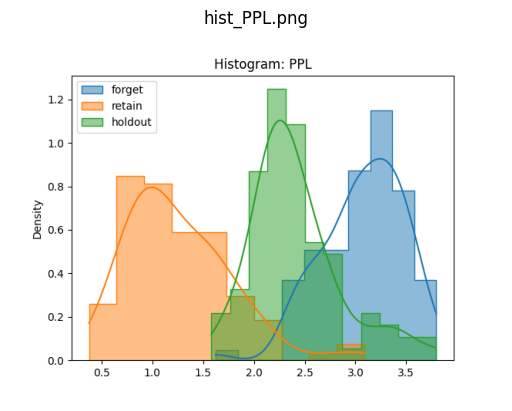

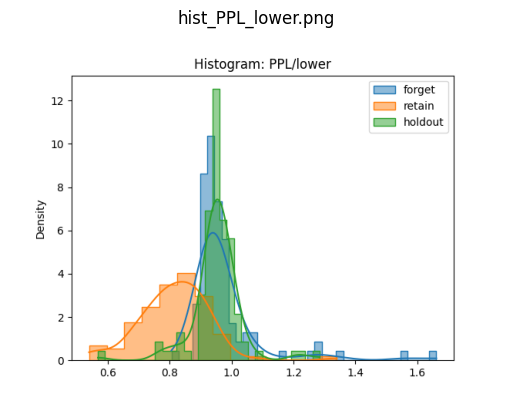

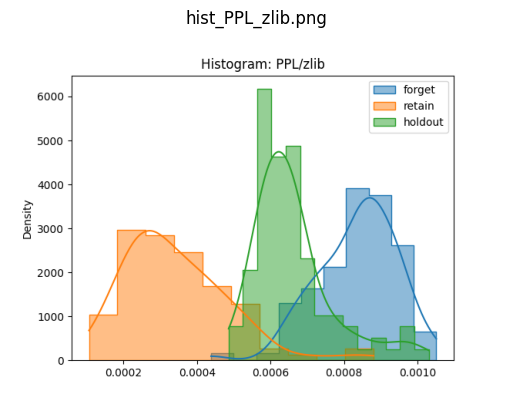

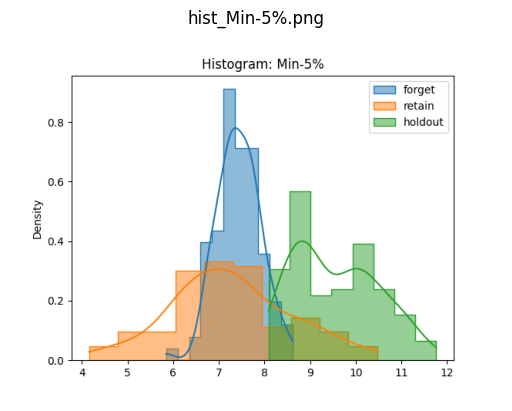

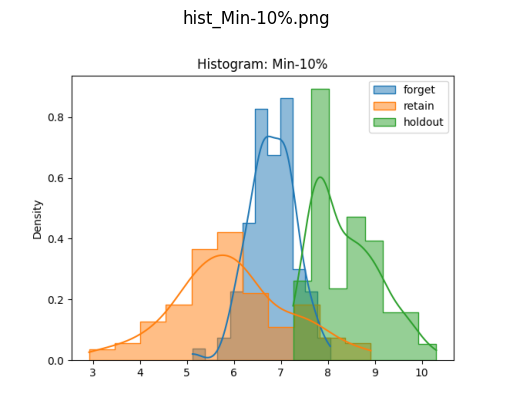

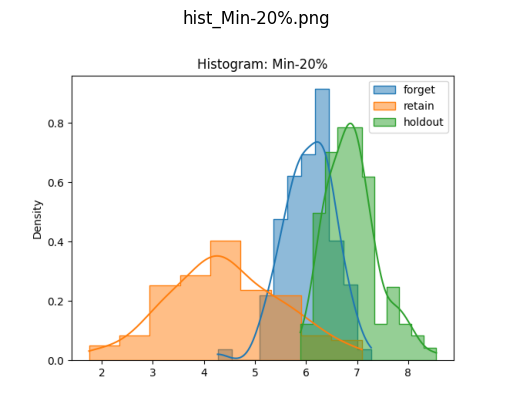

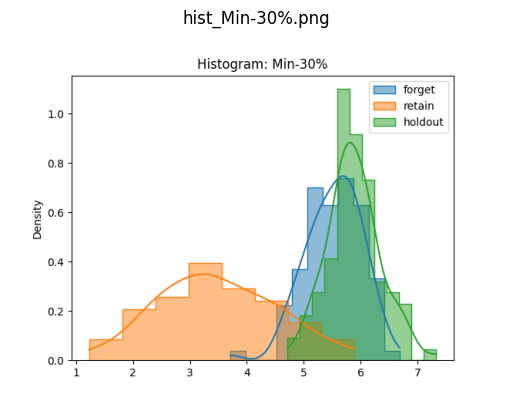

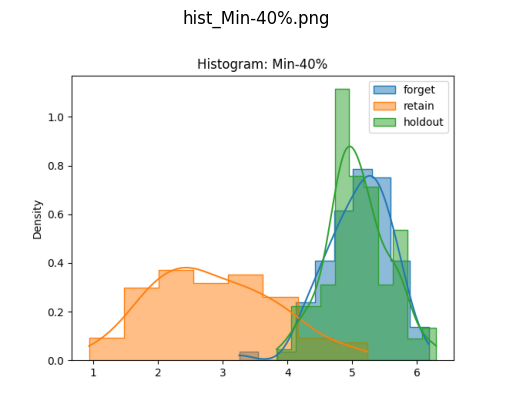

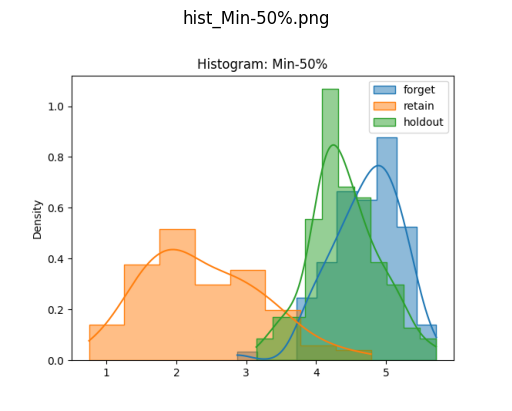

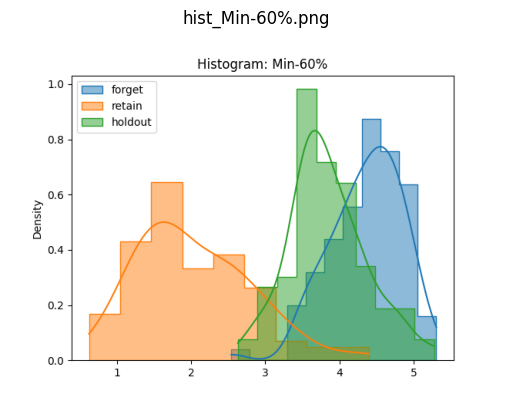

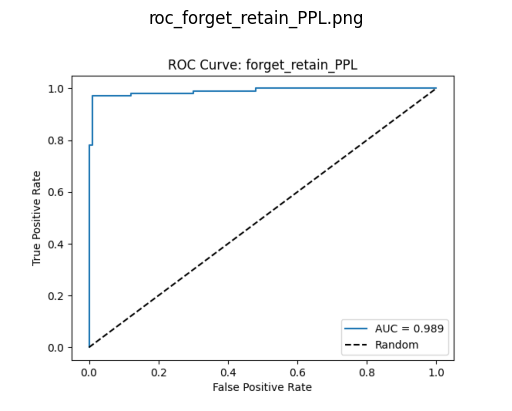

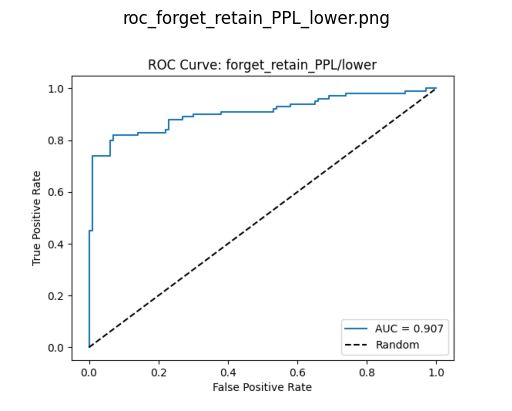

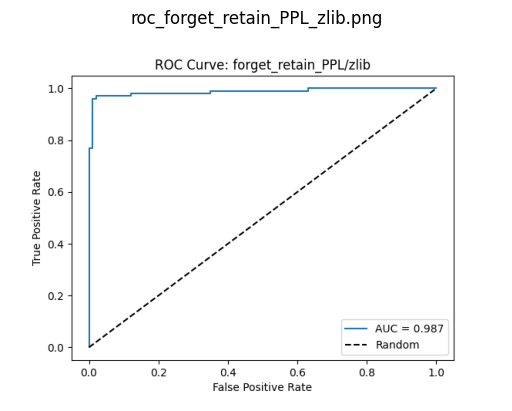

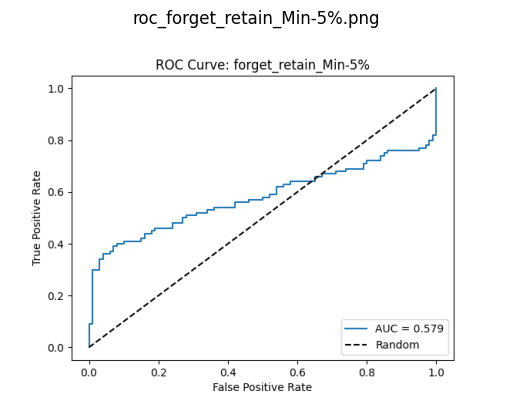

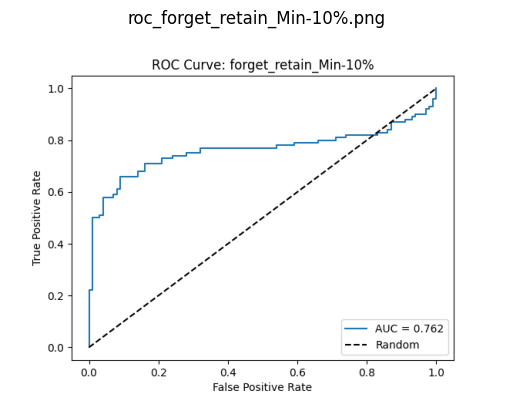

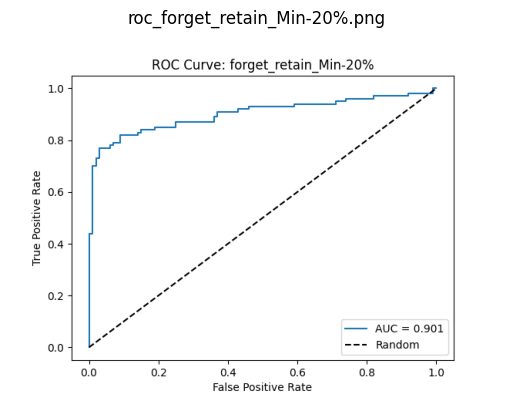

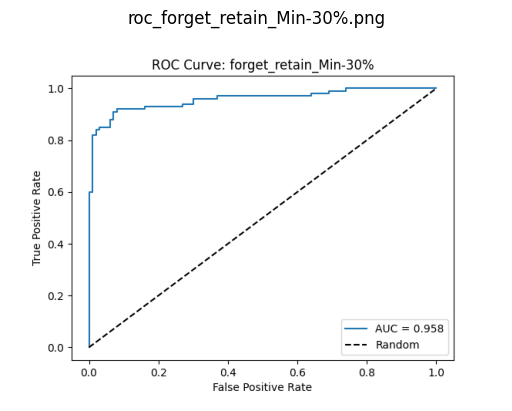

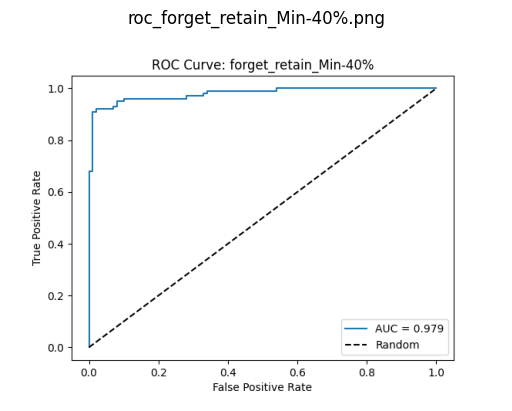

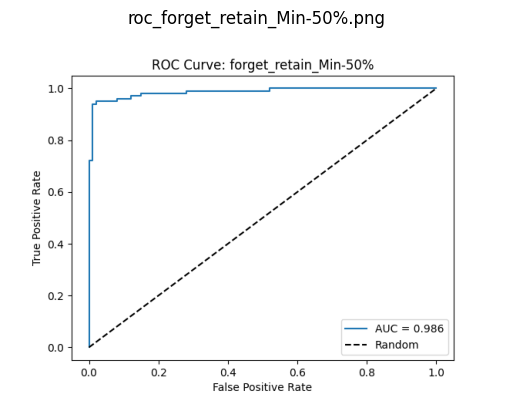

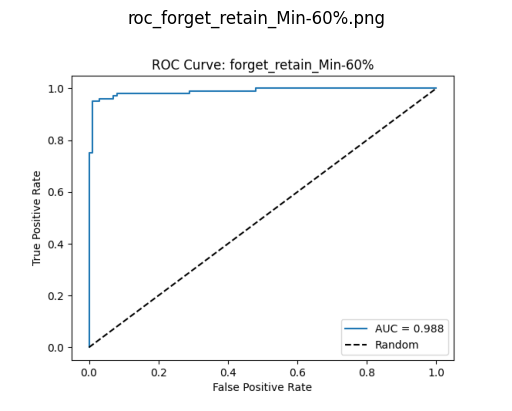

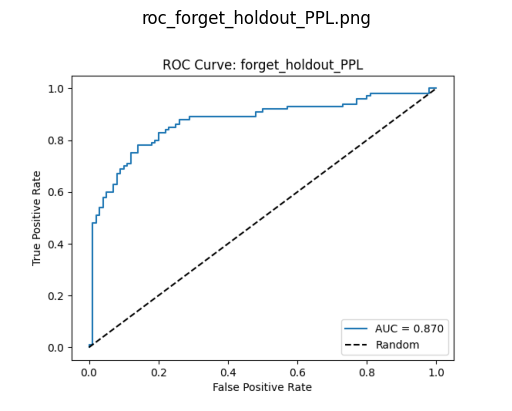

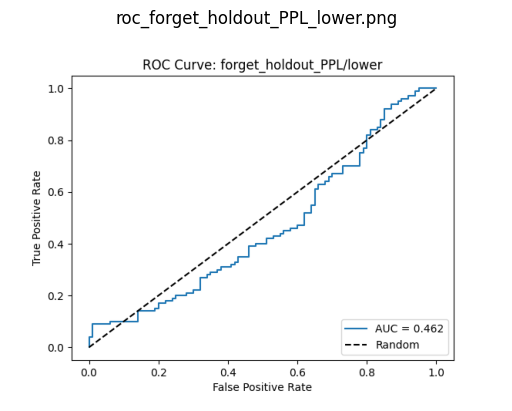

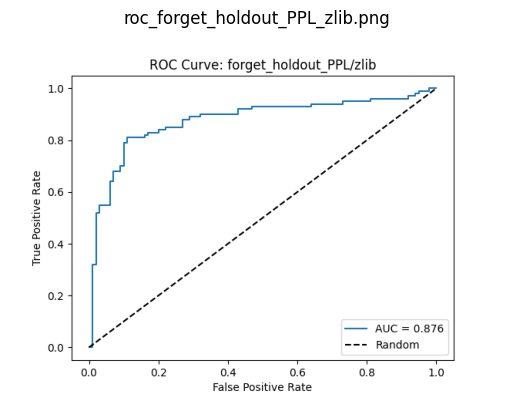

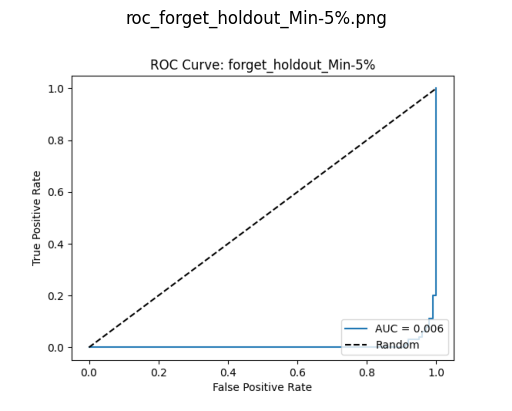

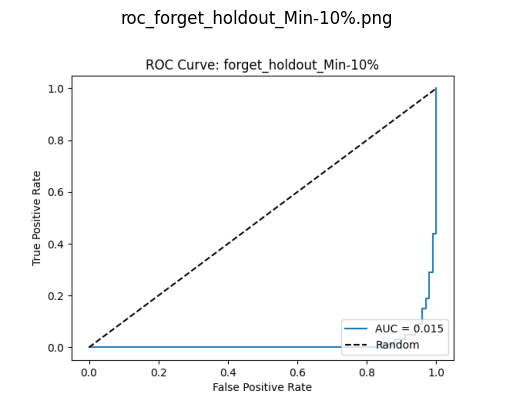

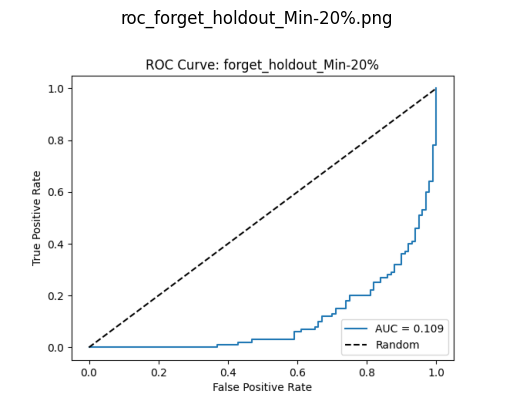

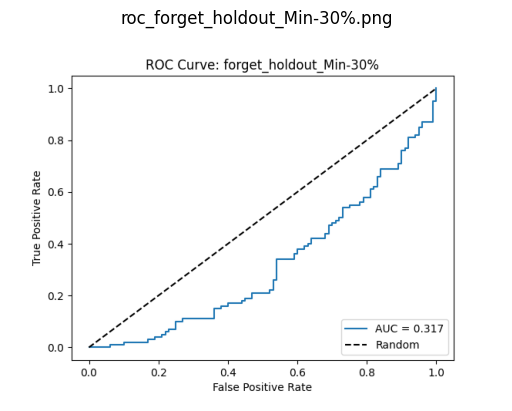

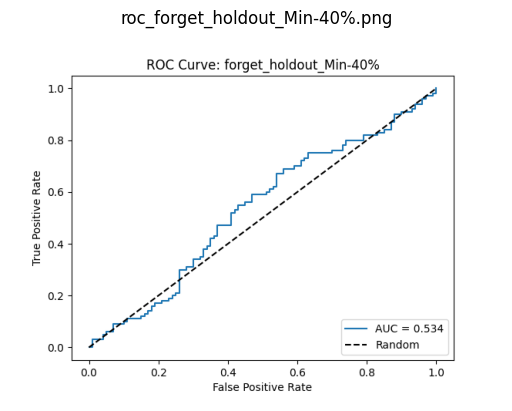

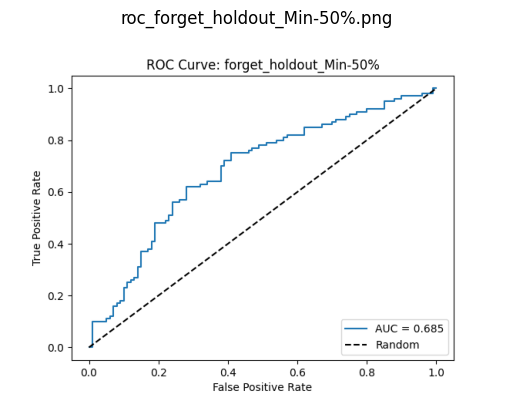

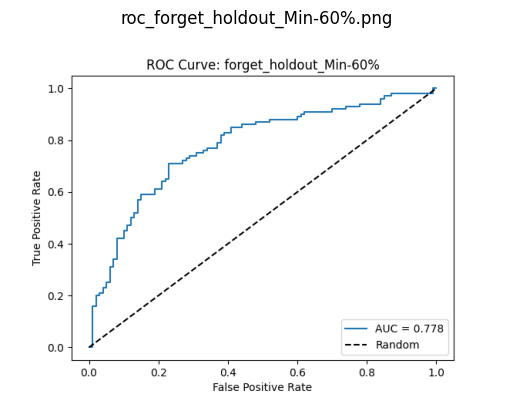

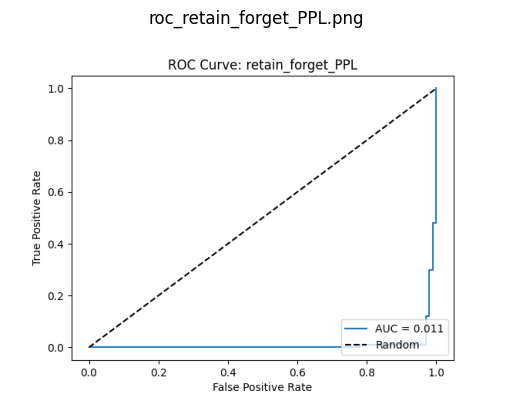

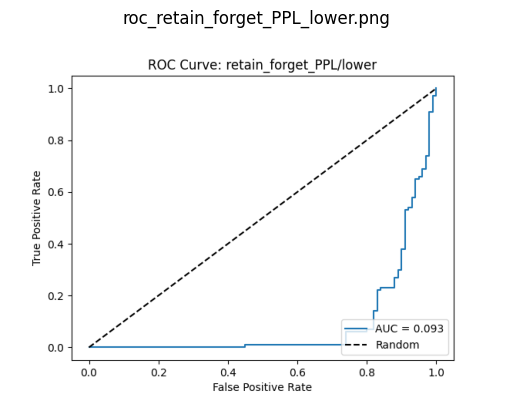

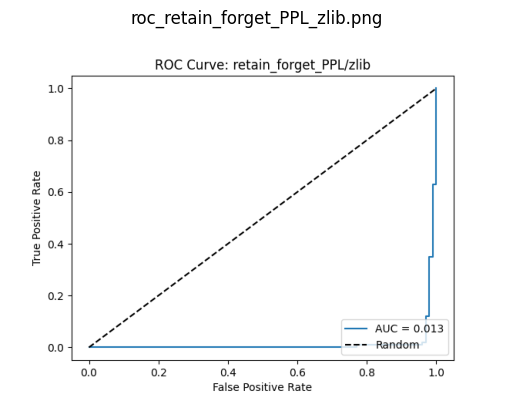

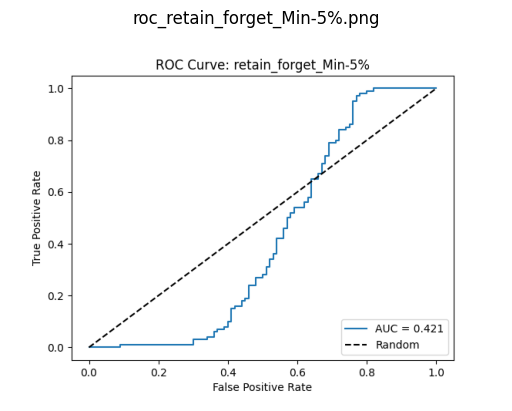

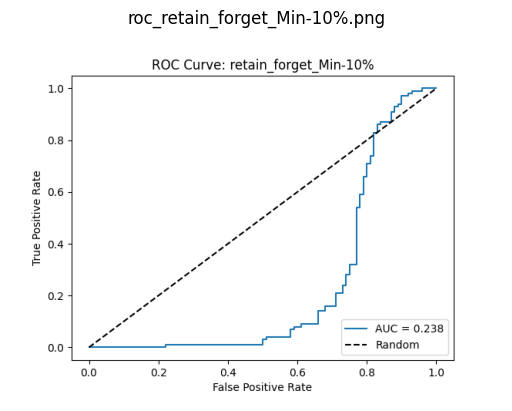

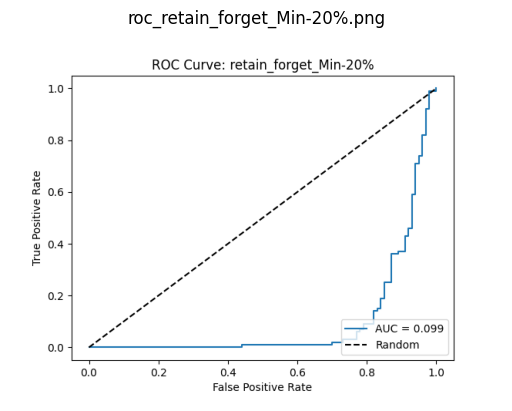

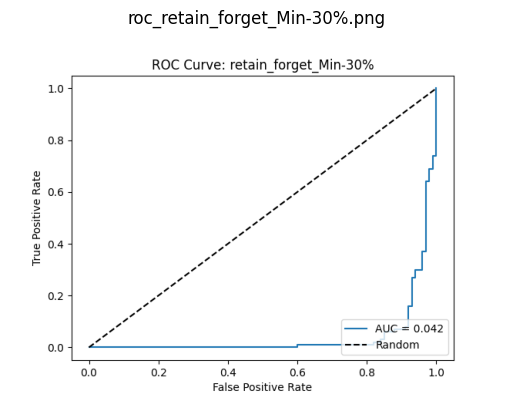

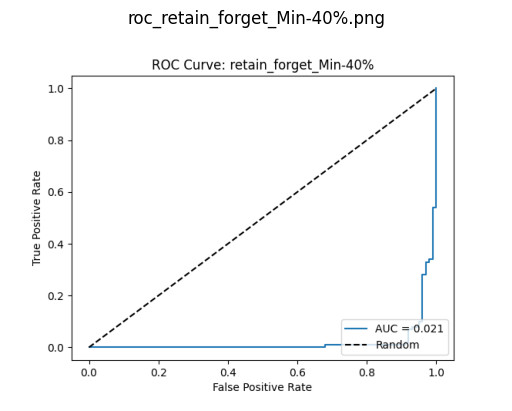

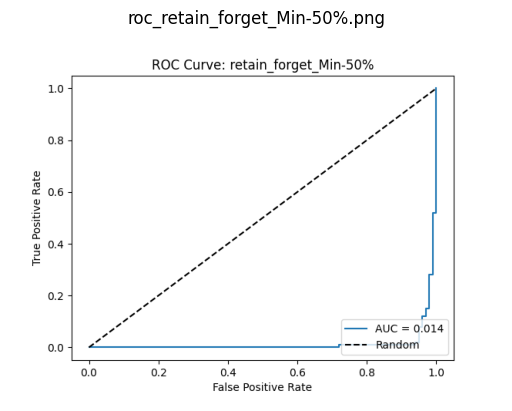

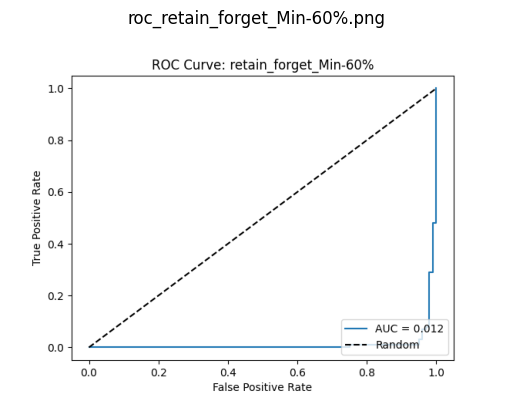

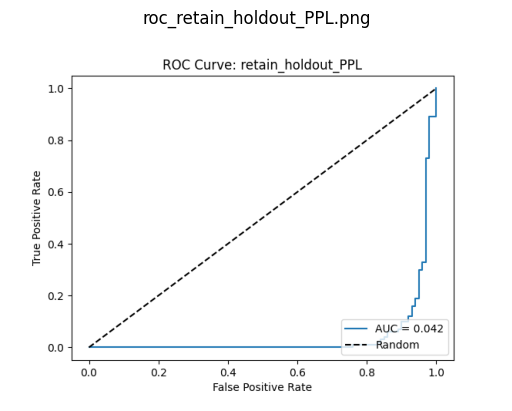

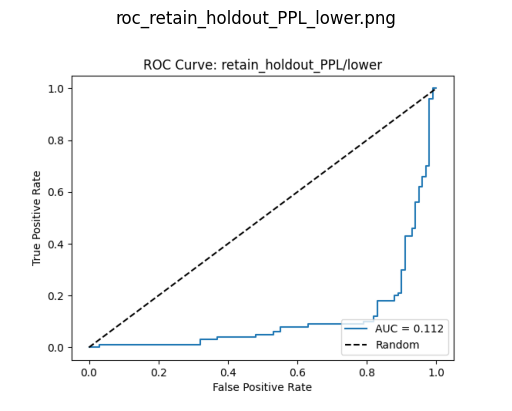

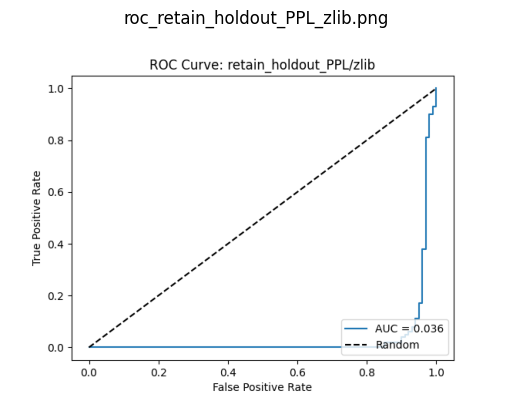

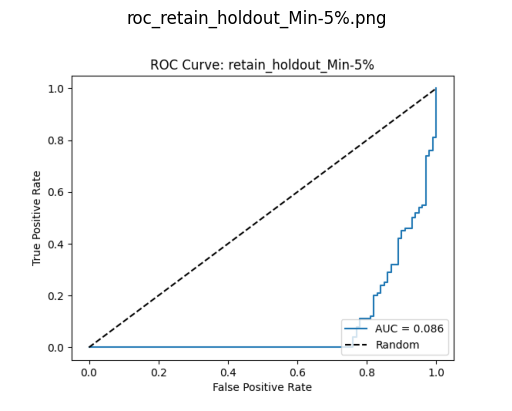

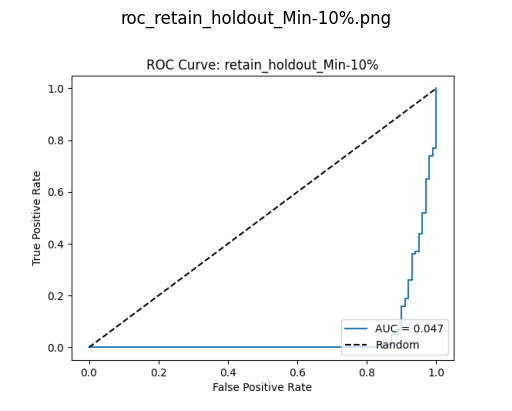

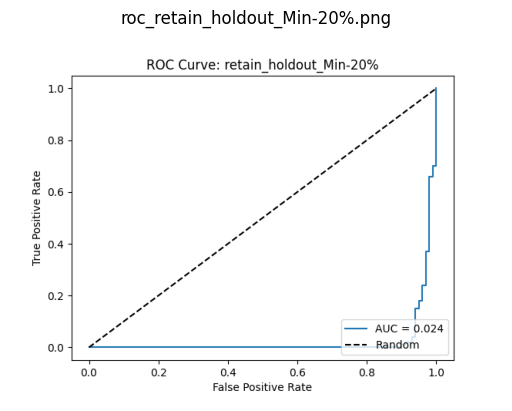

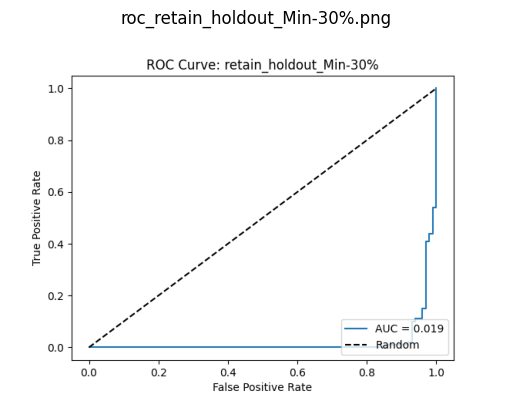

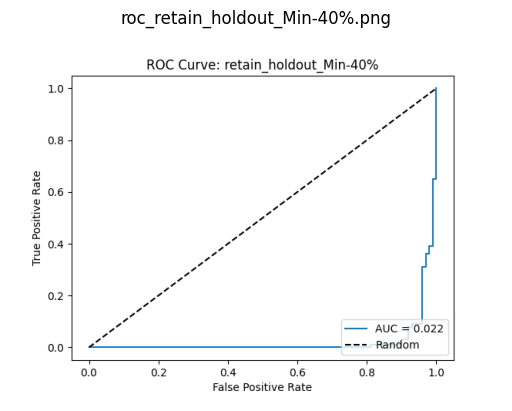

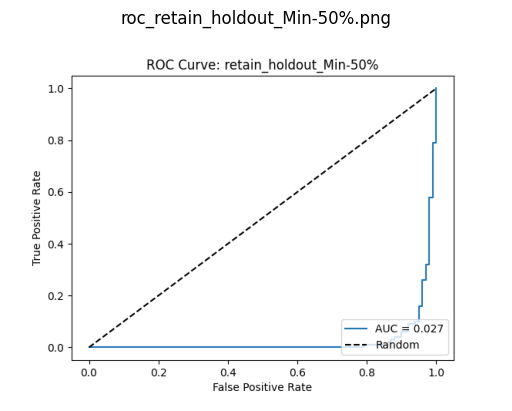

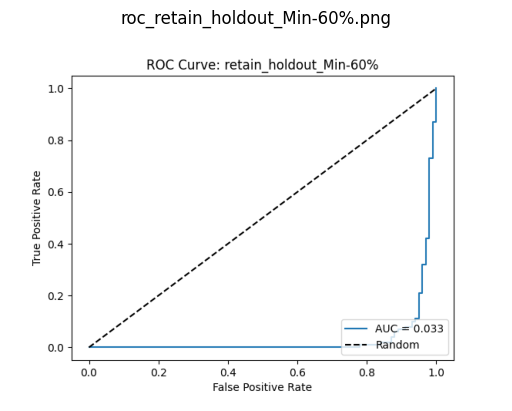

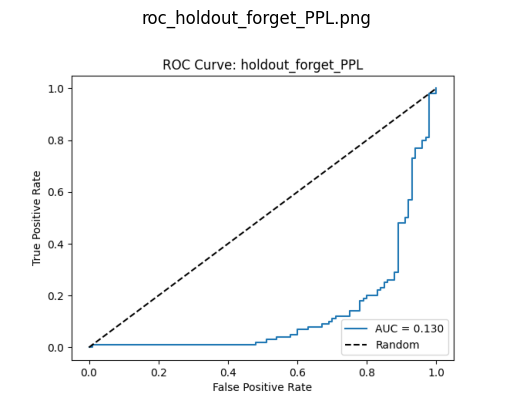

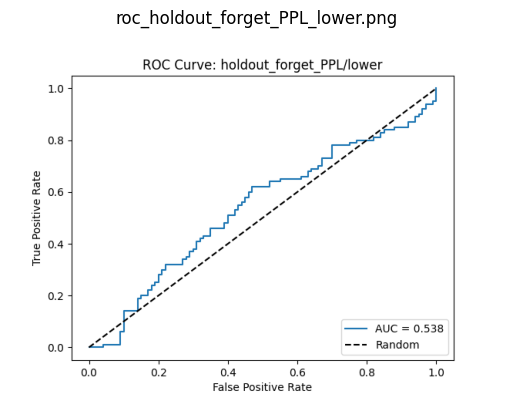

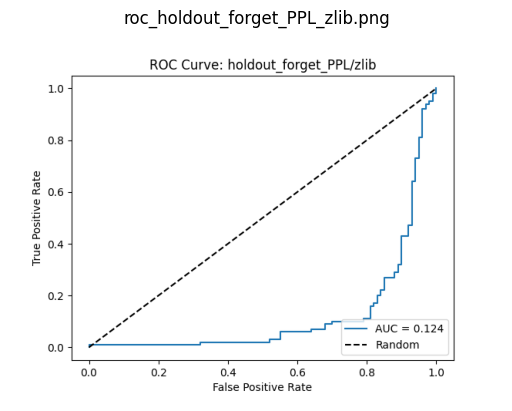

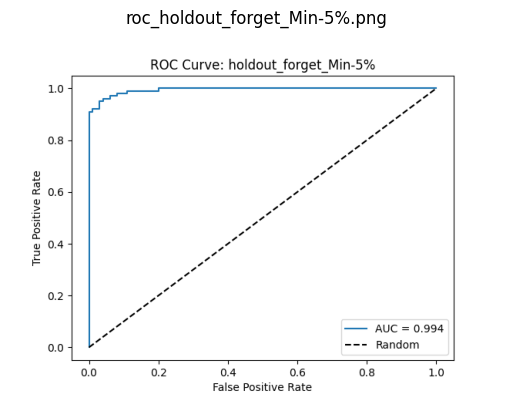

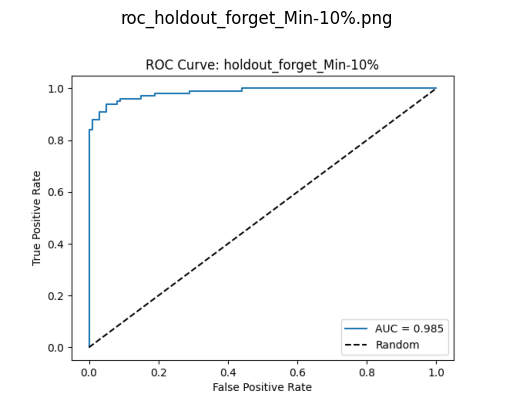

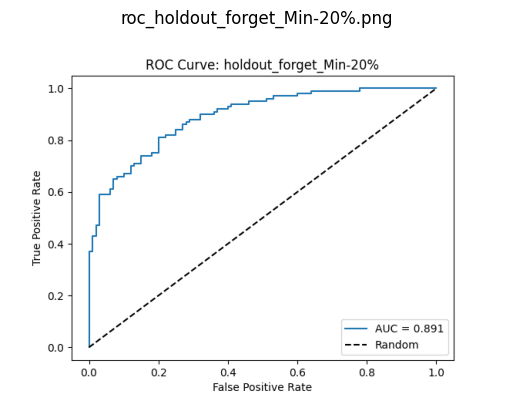

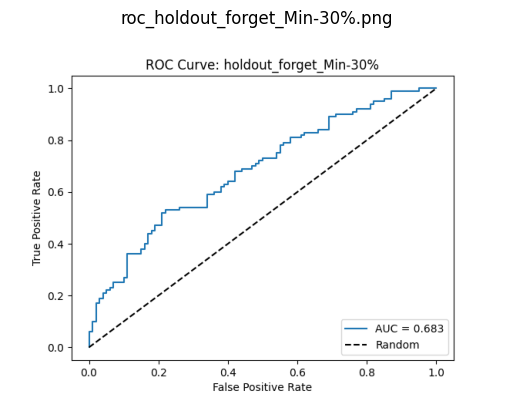

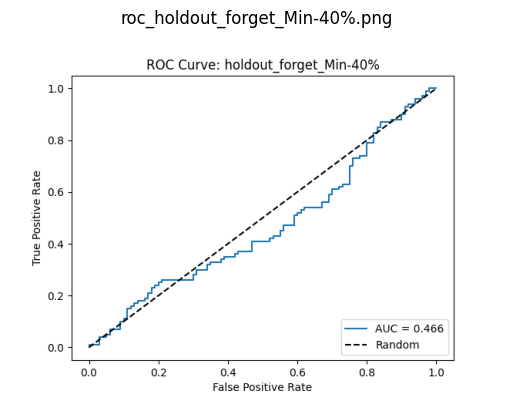

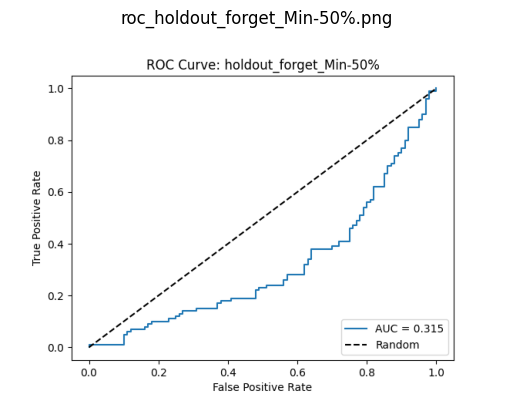

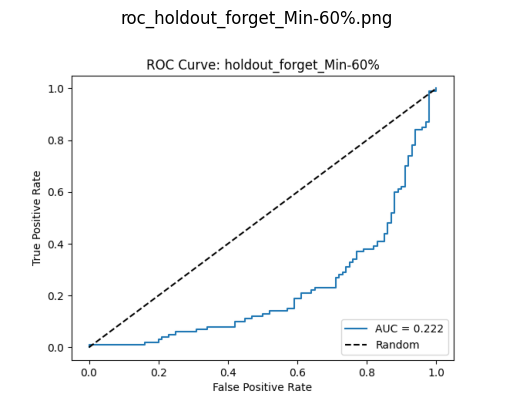

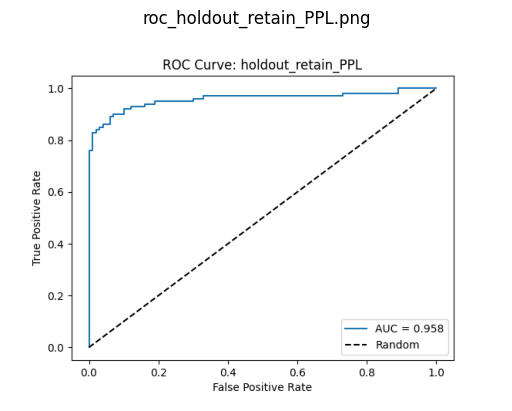

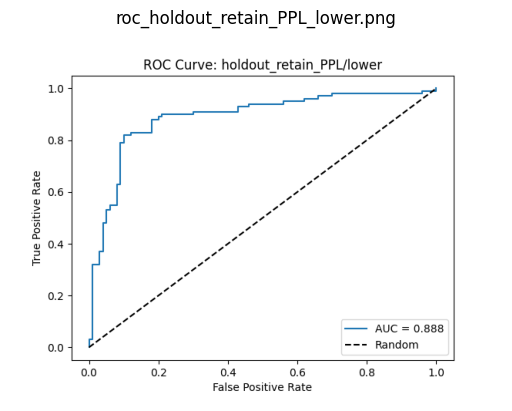

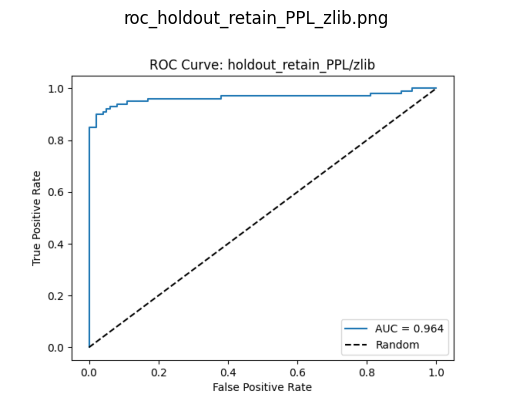

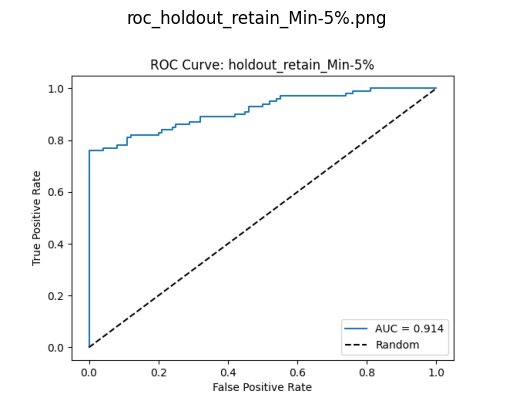

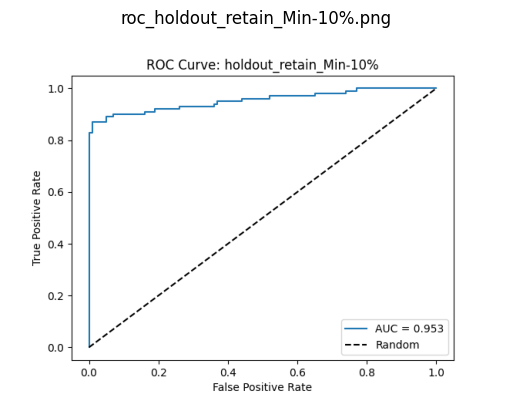

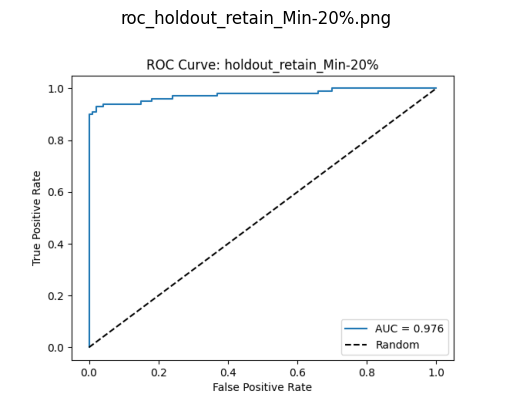

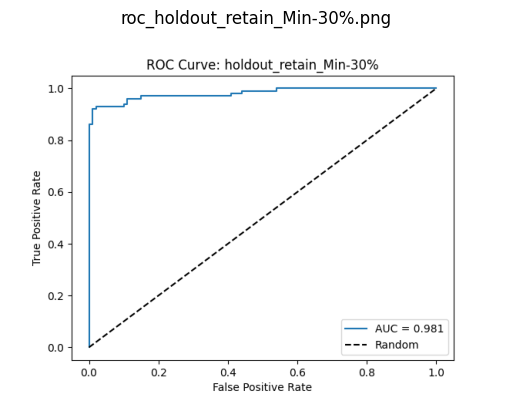

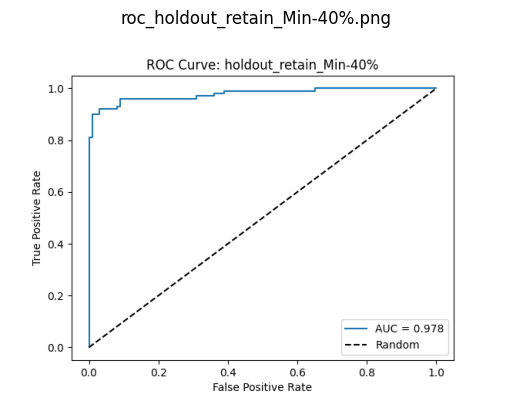

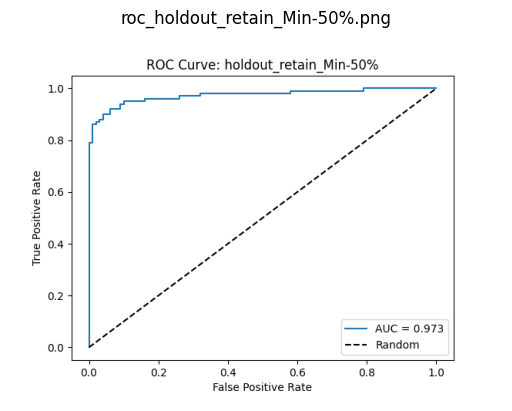

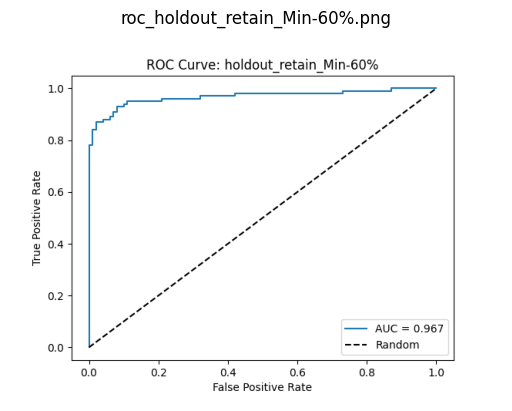

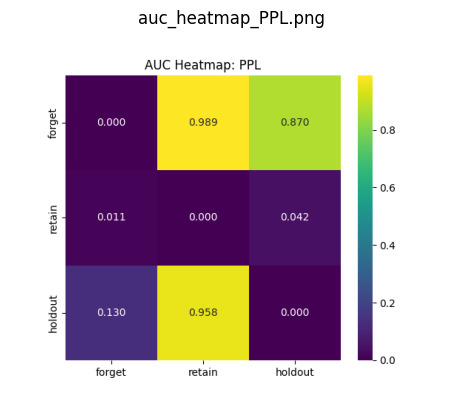

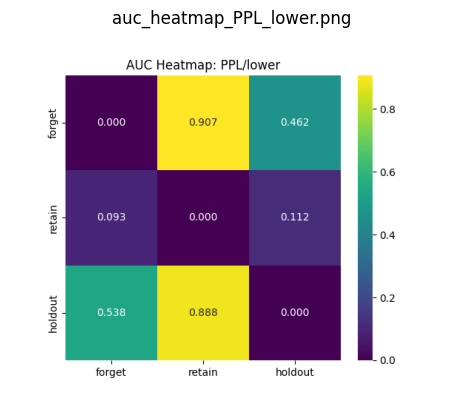

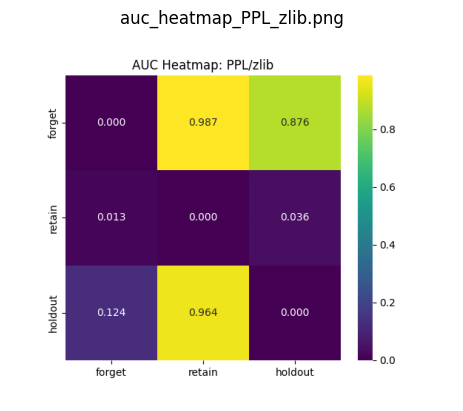

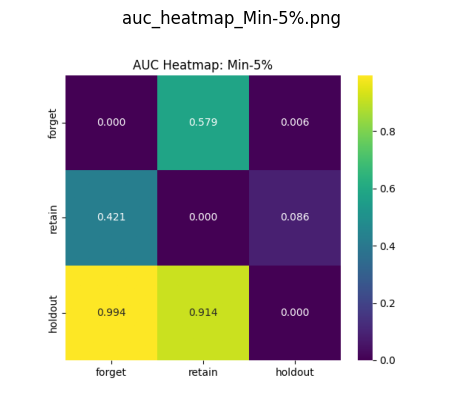

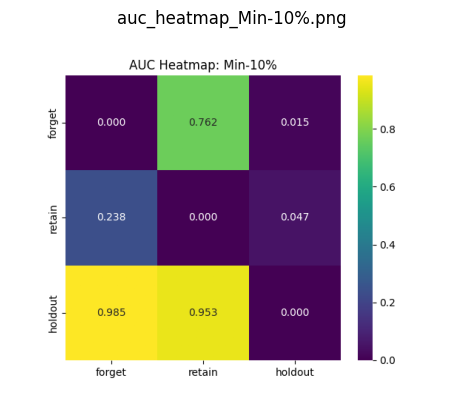

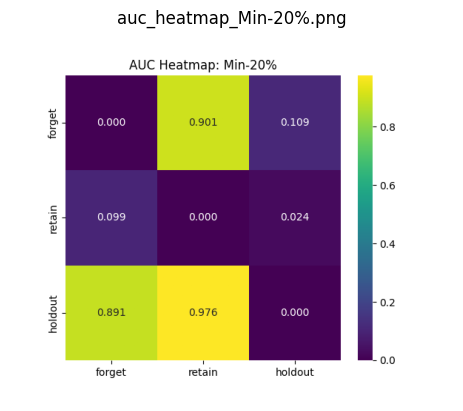

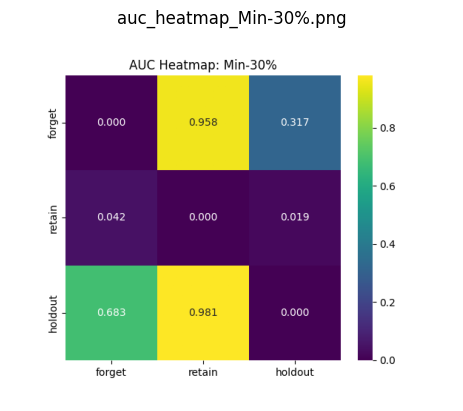

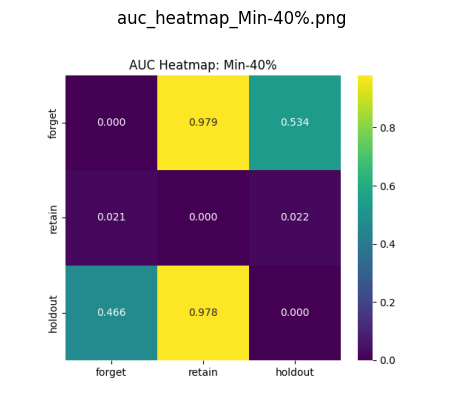

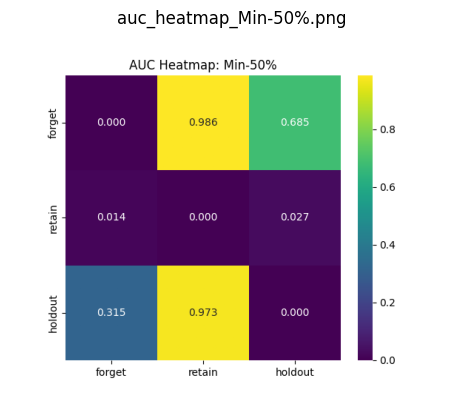

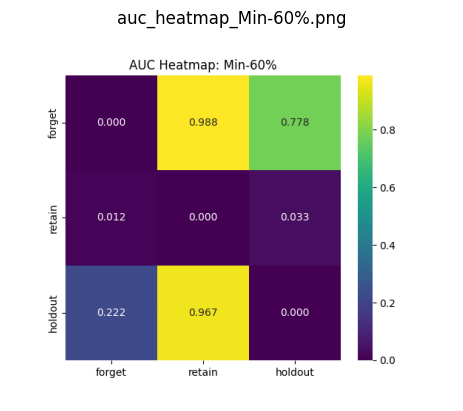

In [6]:
# show all plts under the dir: Unlearn-Simple/MUSE/temp/SimNPO-MUSE-News/privleak
plt_dir = '/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE/temp/SimNPO-MUSE-News/privleak'
import matplotlib.pyplot as plt
import os

def show_all_plots_in_dir(directory):
    for filename in os.listdir(directory):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            file_path = os.path.join(directory, filename)
            img = plt.imread(file_path)
            plt.imshow(img)
            plt.axis('off')  # Hide axes
            plt.title(filename)  # Show the filename as title
            plt.show()
            
show_all_plots_in_dir(plt_dir)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# print(f"{plots=}")
# show plots if available
def show_plots(plots: dict):

    if plots:
        for _, plt_obj in plots.items():
            if isinstance(plt_obj, dict):
                show_plots(plt_obj)
            elif isinstance(plt_obj, str) and os.path.isfile(plt_obj):
                img = mpimg.imread(plt_obj)
                plt.figure()
                plt.imshow(img)
                plt.axis('off')
                plt.title(os.path.basename(plt_obj))
                plt.show()

                
show_plots(plots)

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys

# clean GPU mem
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()



# Import the evaluation function from eval.py
sys.path.append(os.getcwd())
from eval import load_then_eval_models 

# Load your single model and tokenizer
model_name = "OPTML-Group/SimNPO-MUSE-News-llama-2-7b"
tokenizer_dir = "meta-llama/Llama-2-7b-hf"  # Or use model_name if appropriate

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)

# metrics = ["verbmem_f", "privleak", "knowmem_f", "knowmem_r"]  # Optional
out_file_full = os.path.join(os.getcwd(), "simnpo_news_eval.csv")

params = {
    "model_dirs": ["OPTML-Group/SimNPO-MUSE-News-llama-2-7b"],
    "names": ["SimNPO-MUSE-News"],
    "corpus": "news",
    "out_file": out_file_full,
    "metrics": ['loss_landscape'], #["privleak", "verbmem_f", "knowmem_f", "knowmem_r", "loss_landscape"],
    "tokenizer_dir": "meta-llama/Llama-2-7b-hf",
    "temp_dir": "temp",
    "DEBUG": True
}

model_name='distilgpt2-finetuned-wikitext2'
create_new_file = False

forget_data, retain_data, holdout_data, model, tokenizer, loss_landscape = load_then_eval_models(**params)

Current working directory: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE
/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE/simnpo_news_eval.csv


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

DEBUG=True


In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'src')))
import input_loss_landscape.utils as input_loss_landscape_utils

#print input_loss_landscape_utils attributes
print(dir(input_loss_landscape_utils))

input_loss_landscape_eval = input_loss_landscape_utils.input_loss_landscape_eval


['Dataset', 'LogisticRegression', 'PROJECT_PATH', 'RandomForestClassifier', 'SentenceTransformer', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy_score', 'attacker_module', 'attacker_path', 'compute_circle_landscape_data', 'extract_features', 'f1_score', 'generate_text_and_neighbors_from_dataset', 'get_auc', 'get_roc_curve', 'get_subset', 'importlib', 'input_loss_landscape_attack', 'input_loss_landscape_eval', 'main', 'normalize_feature_tensors_with_scaler', 'np', 'os', 'pd', 'plot_equator_distance_barplot', 'plot_feature_distributions_per_radius', 'plot_landscape_results', 'plot_member_nonmember_differences_normalized', 'plot_member_values_across_radii', 'plot_radius_analysis', 'plt', 'precision_recall_curve', 'random', 'roc_auc_score', 'sns', 'spec', 'take_max_subset_from_data_dict', 'torch', 'tqdm', 'train_circle_predictors', 'train_test_split', 'umap', 'warnings']


In [2]:
%autoreload 2

import json


privleak_forget_file = 'data/news/privleak/forget.json'
privleak_retain_file = 'data/news/privleak/retain.json'
privleak_holdout_file = 'data/news/privleak/holdout.json'

def read_json(fpath: str):
    with open(fpath, 'r') as f:
        return json.load(f)

forget_data = read_json(privleak_forget_file)
retain_data = read_json(privleak_retain_file)
holdout_data = read_json(privleak_holdout_file)

subset_len = 30
forget_data = forget_data[:subset_len]
retain_data = retain_data[:subset_len]
holdout_data = holdout_data[:subset_len]

    
len(forget_data), len(retain_data), len(holdout_data)

auc, log, loss_landscape_plots = input_loss_landscape_eval(
        forget_data=forget_data,
        retain_data=retain_data,
        holdout_data=holdout_data,
        model=model, tokenizer=tokenizer,
        plot_dir=loss_landscape,
        model_name='distilgpt2-finetuned-wikitext2',
        create_new_file=False,
    )

NameError: name 'input_loss_landscape_eval' is not defined

CSV file: feature_summary.csv


,Feature,Split,Mean,Std,Min,Max
0,original_loss,forget,9.120793,1.067099,7.318629,10.067354
1,original_loss,retain,9.120793,1.067099,7.318629,10.067354
2,original_loss,holdout,9.120793,1.067099,7.318629,10.067354
3,mean_neighbor_loss,forget,9.673409,0.783412,8.615493,10.560725
4,mean_neighbor_loss,retain,9.673409,0.783412,8.615493,10.560725
5,mean_neighbor_loss,holdout,9.673409,0.783412,8.615493,10.560725
6,max_neighbor_loss,forget,10.421053,0.749666,9.059343,11.170559
7,max_neighbor_loss,retain,10.421053,0.749666,9.059343,11.170559
8,max_neighbor_loss,holdout,10.421053,0.749666,9.059343,11.170559
9,min_neighbor_loss,forget,9.106379,0.701078,8.233350,9.916529


[Showing 20/45 rows from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE/temp/SimNPO-MUSE-News/loss_landscape/feature_summary.csv]


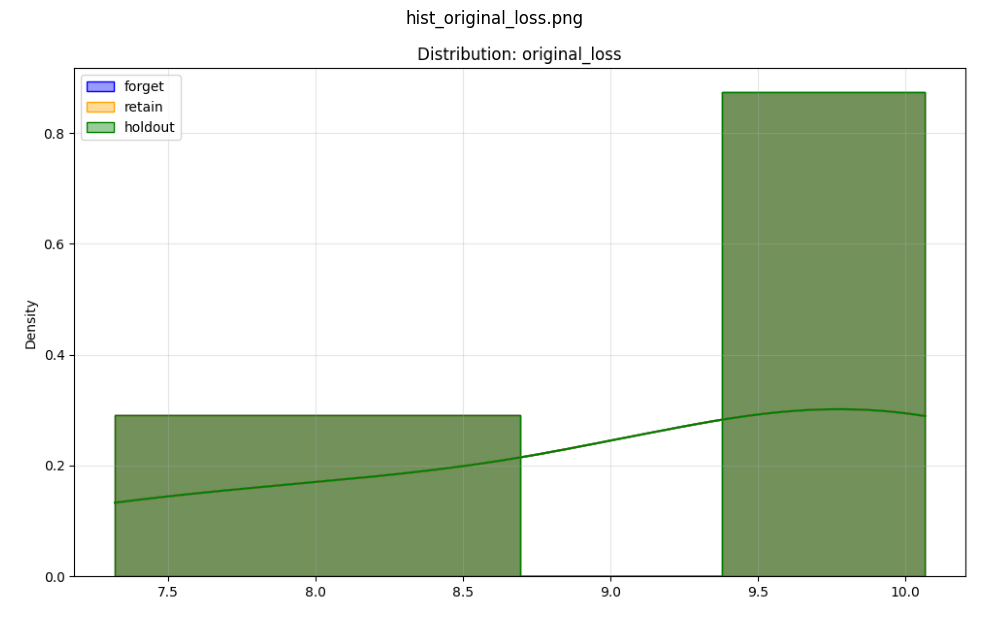

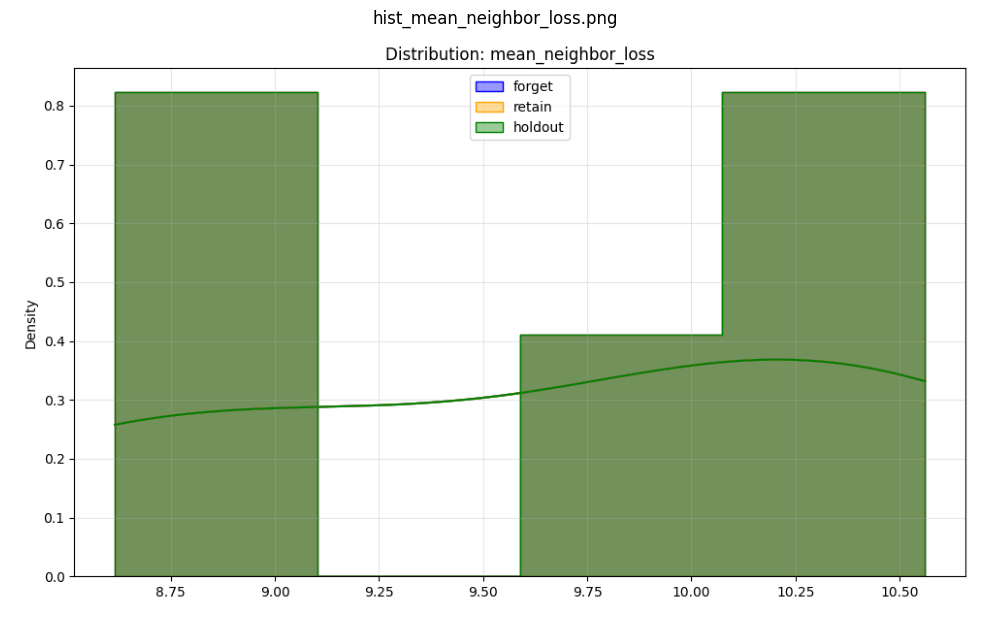

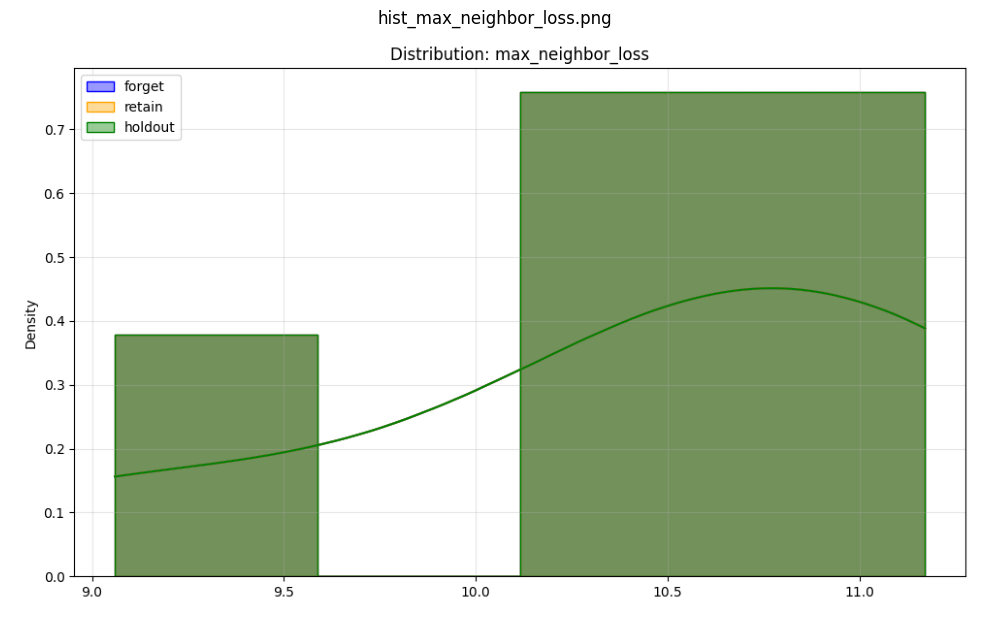

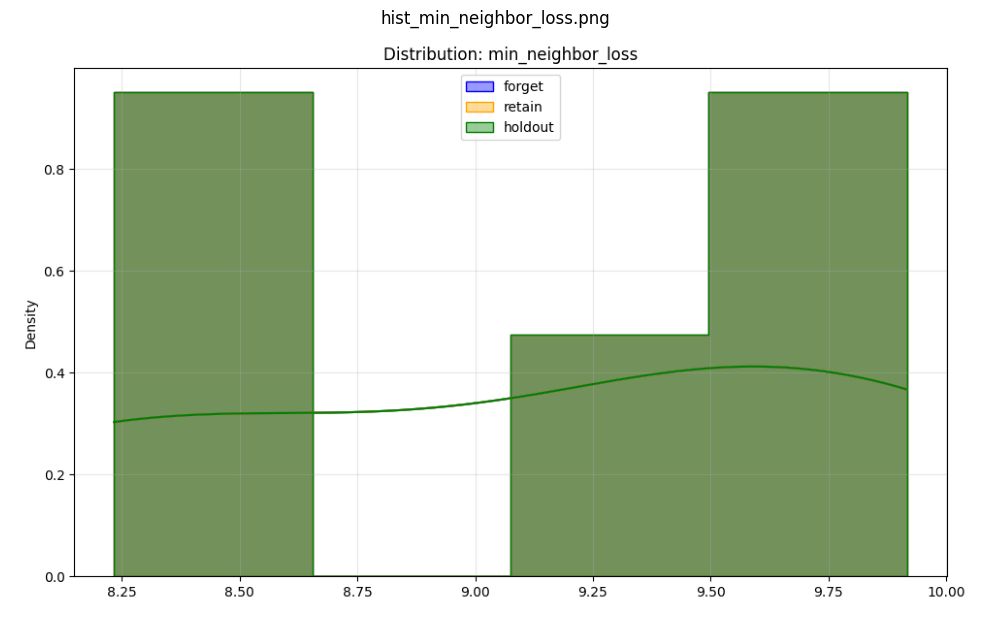

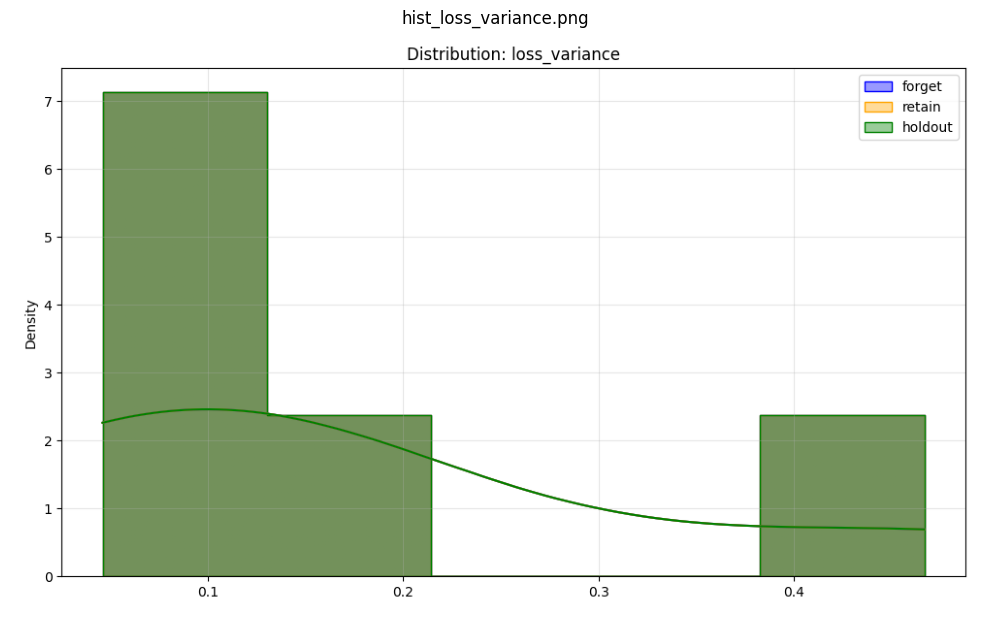

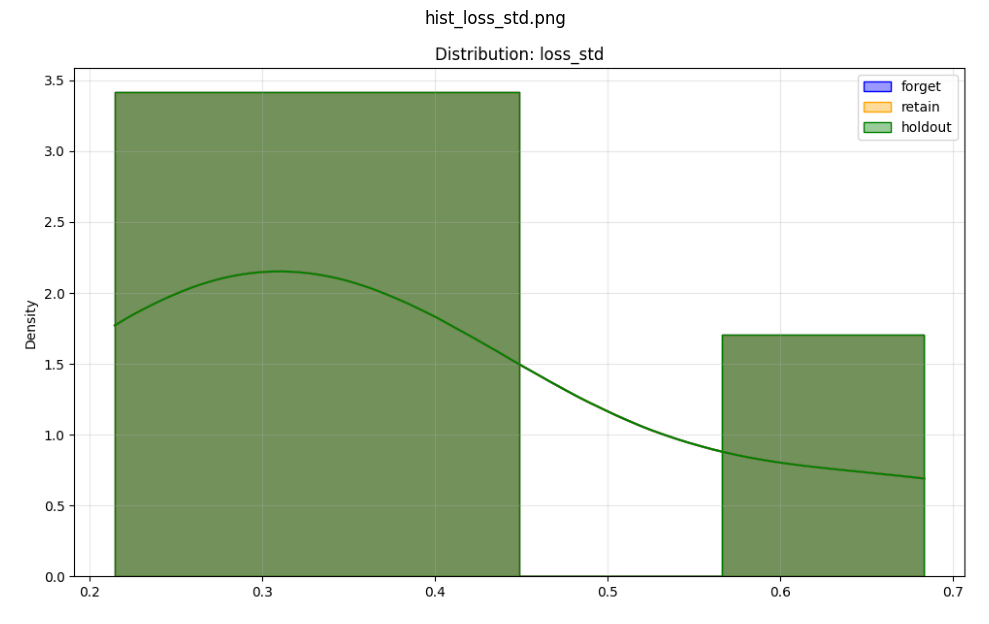

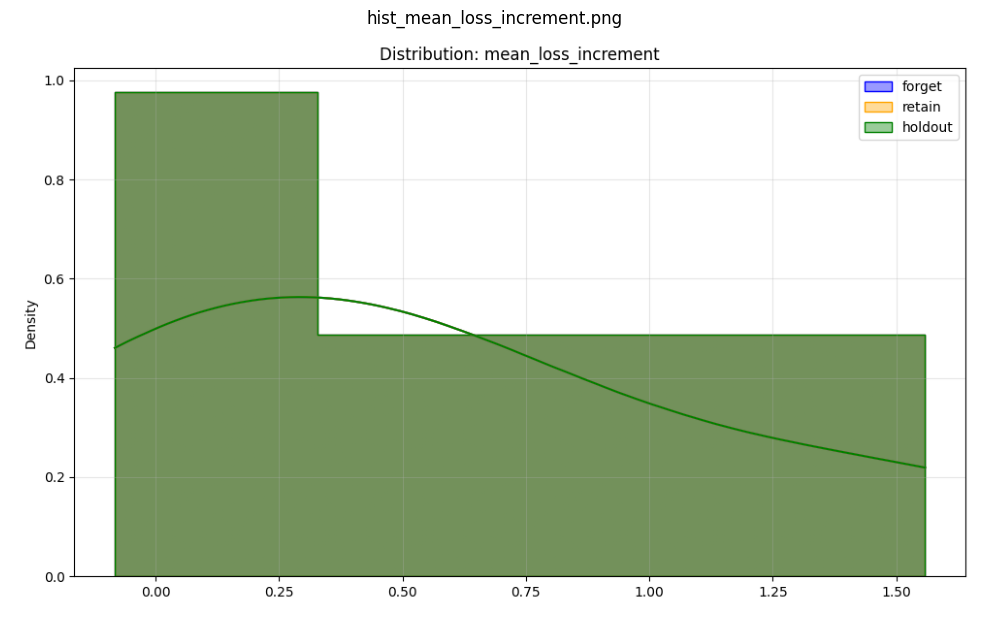

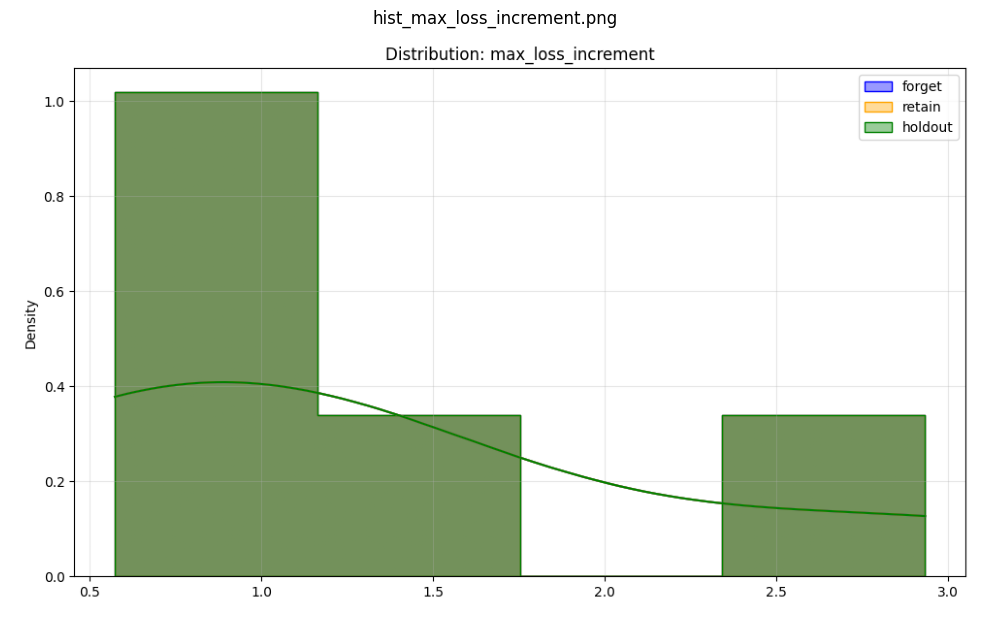

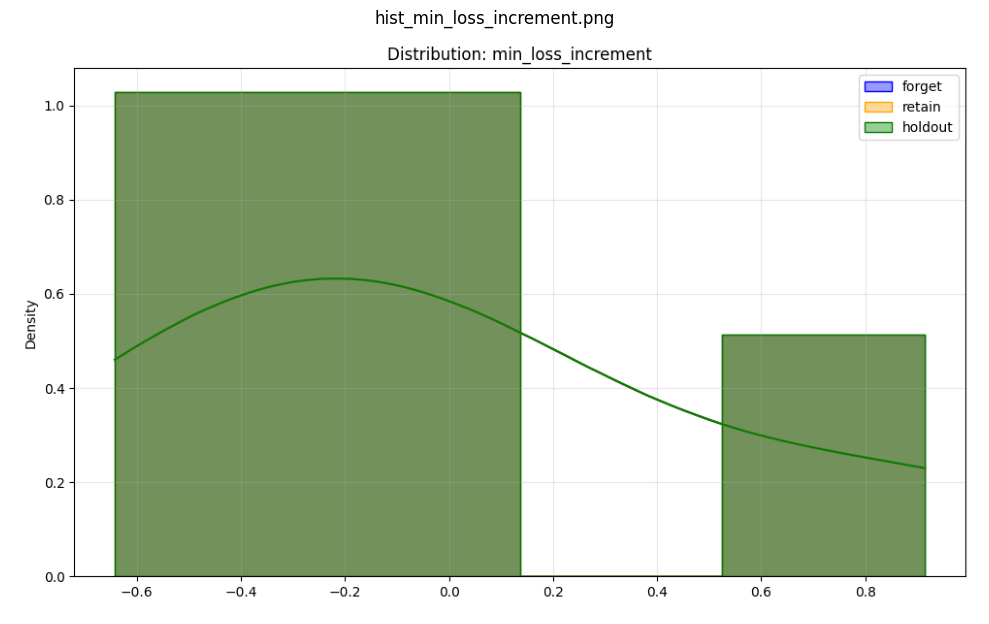

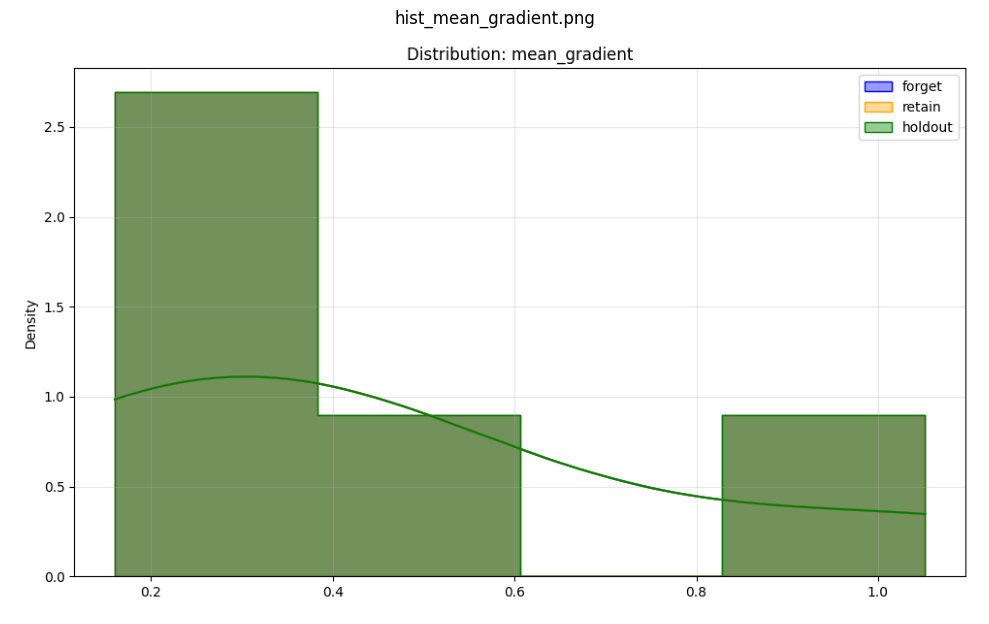

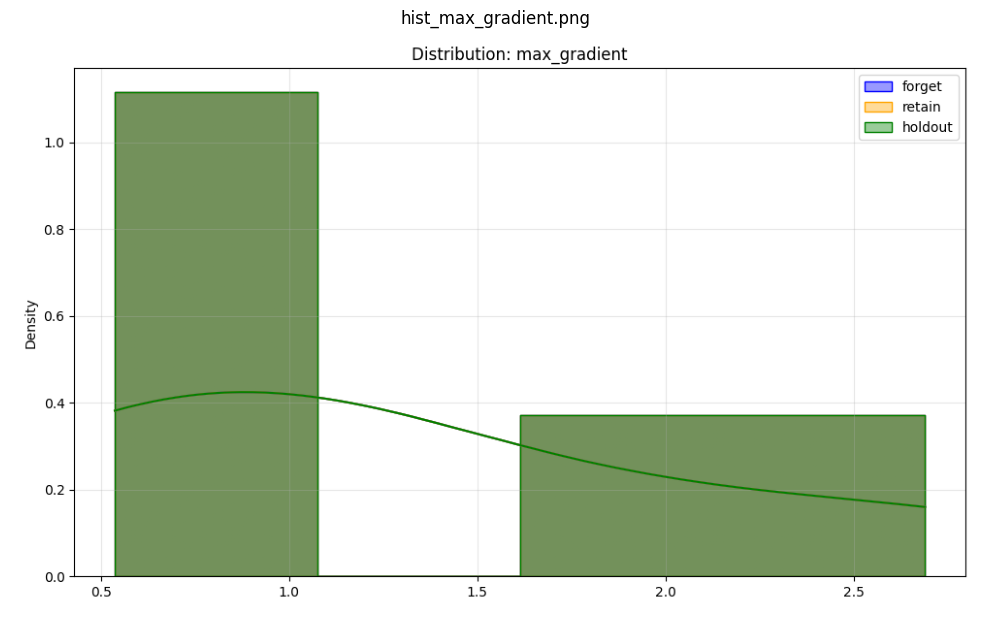

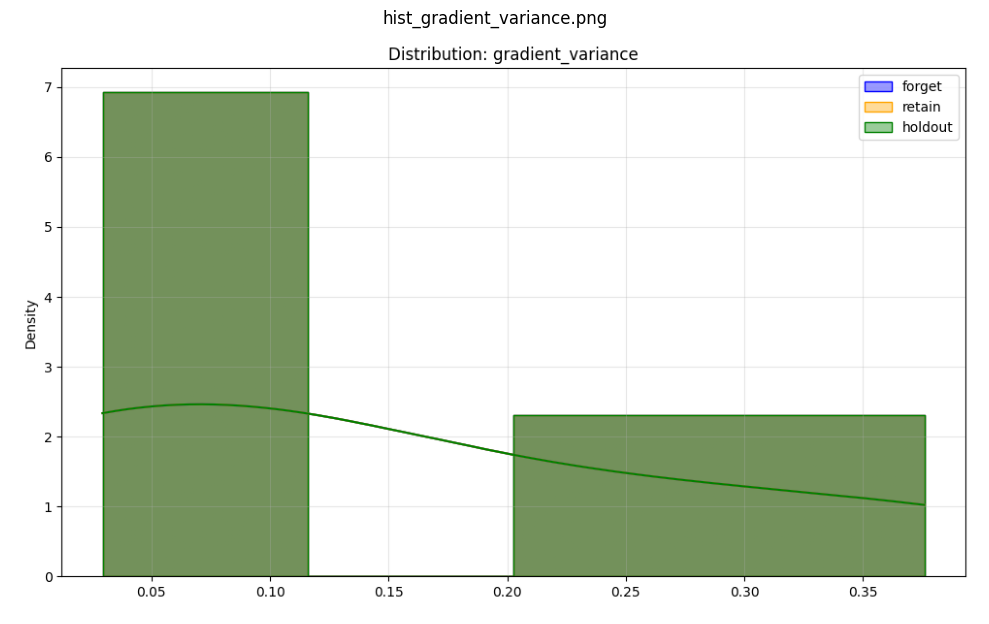

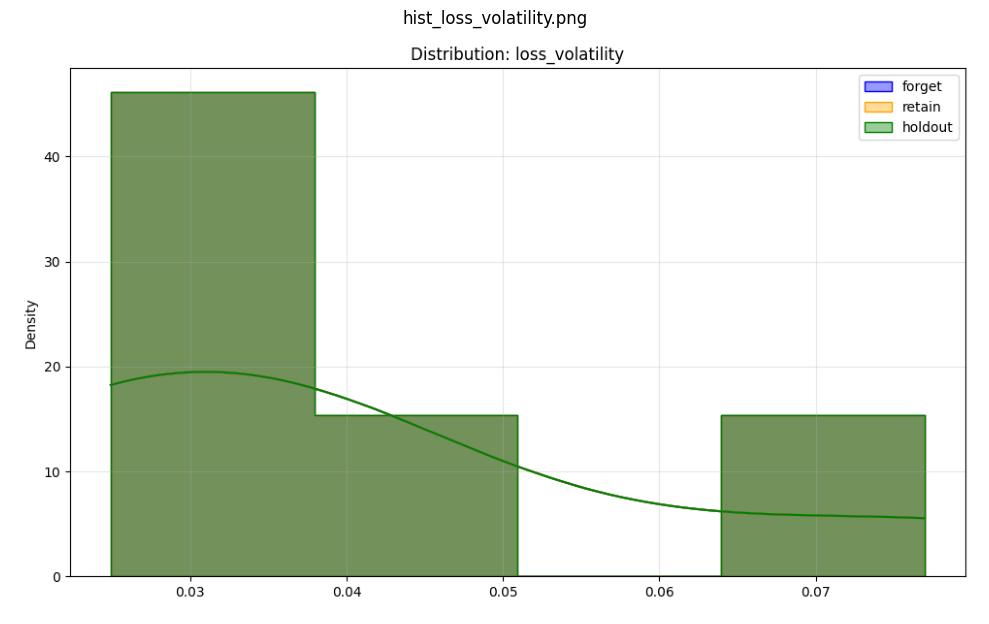

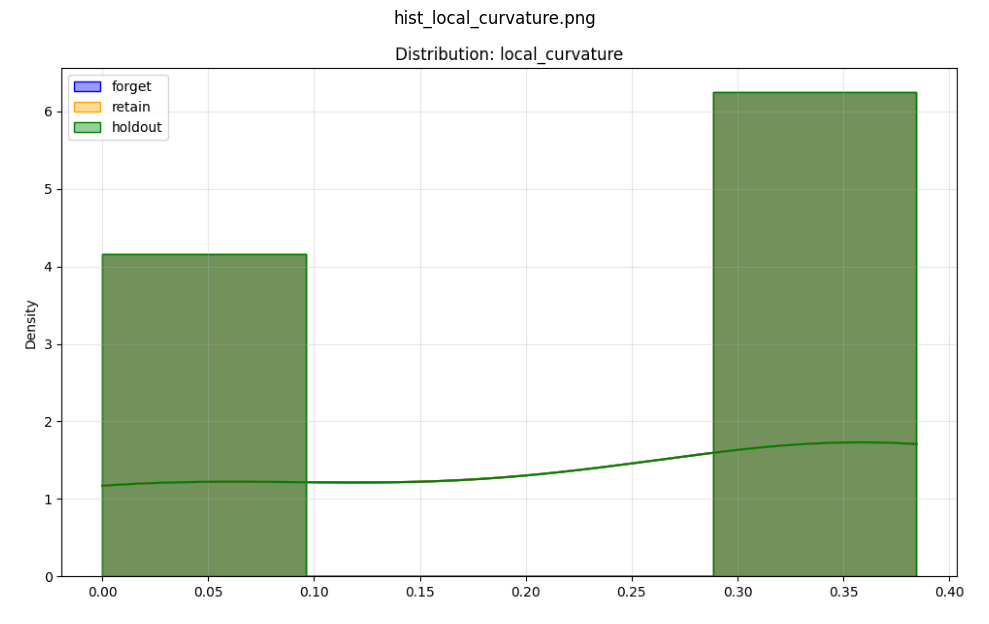

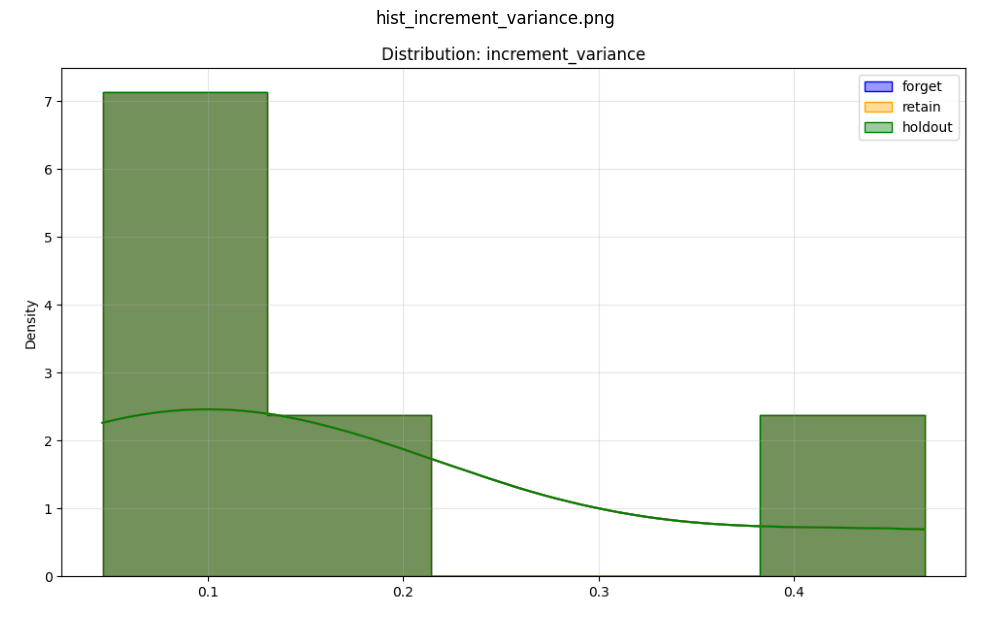

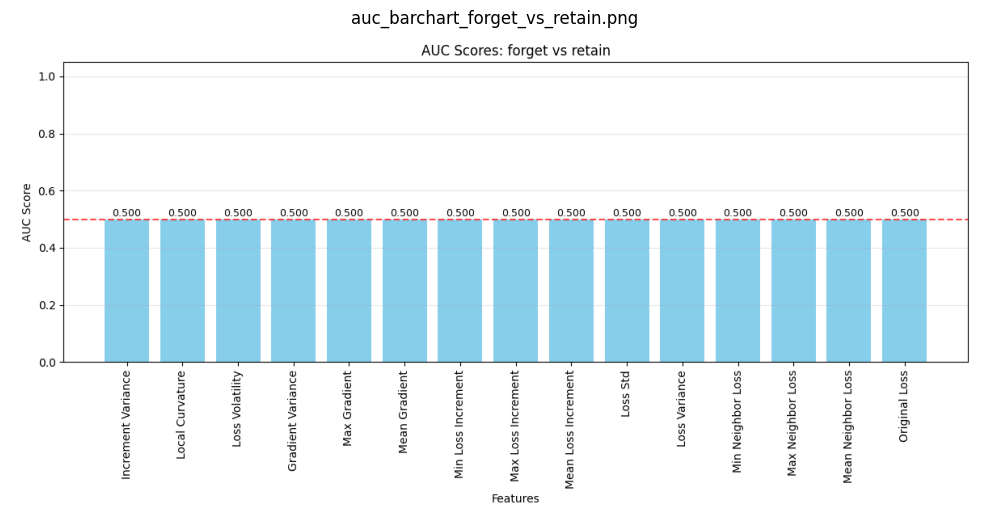

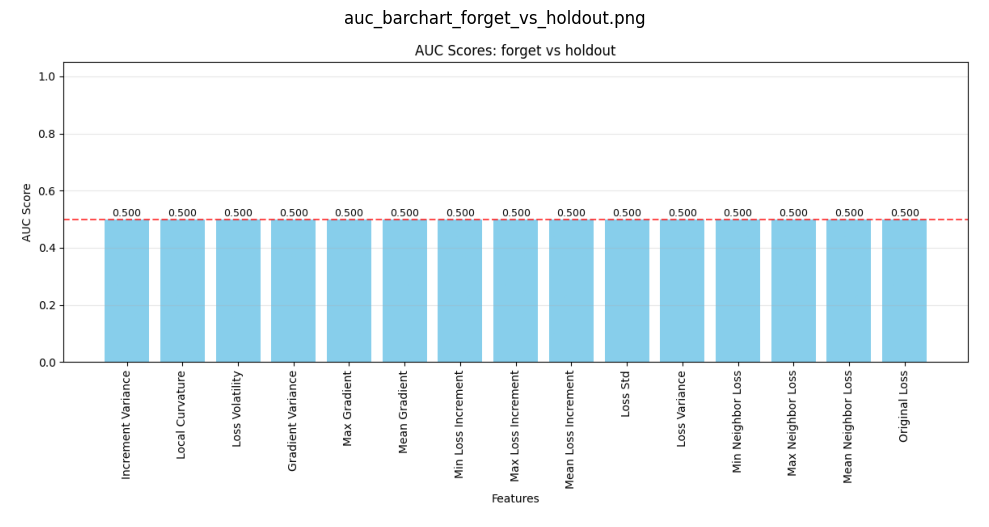

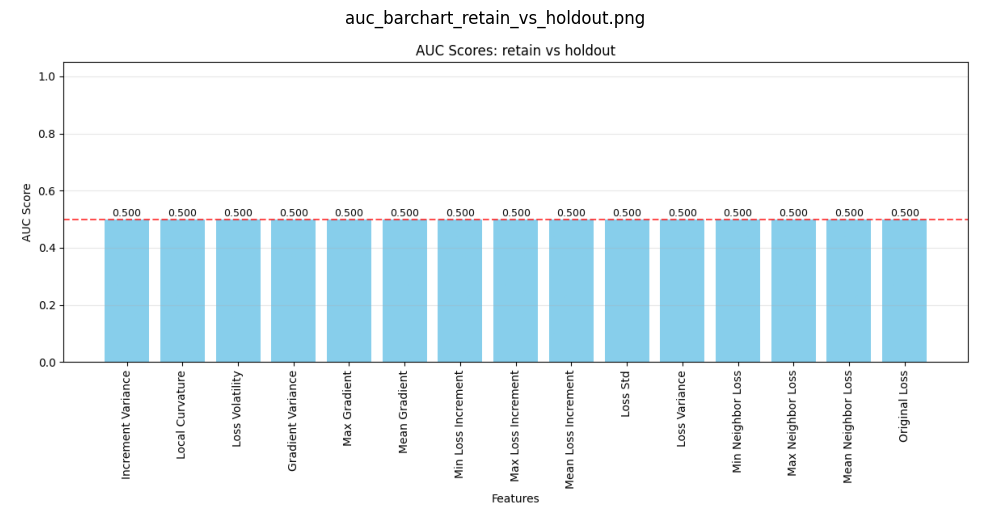

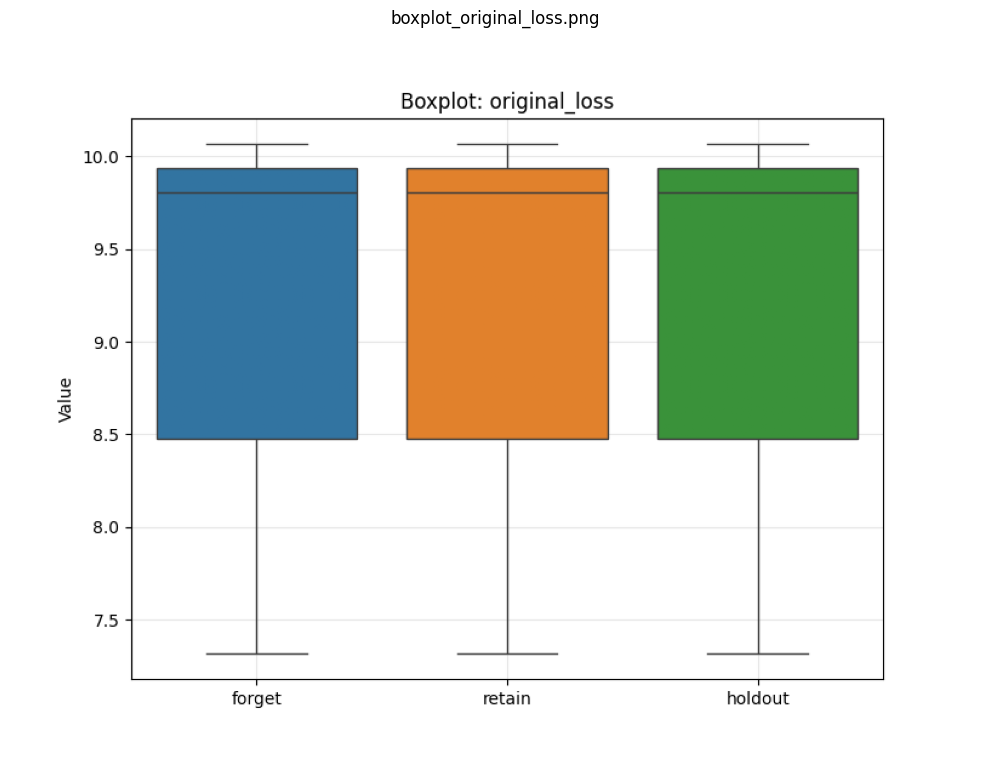

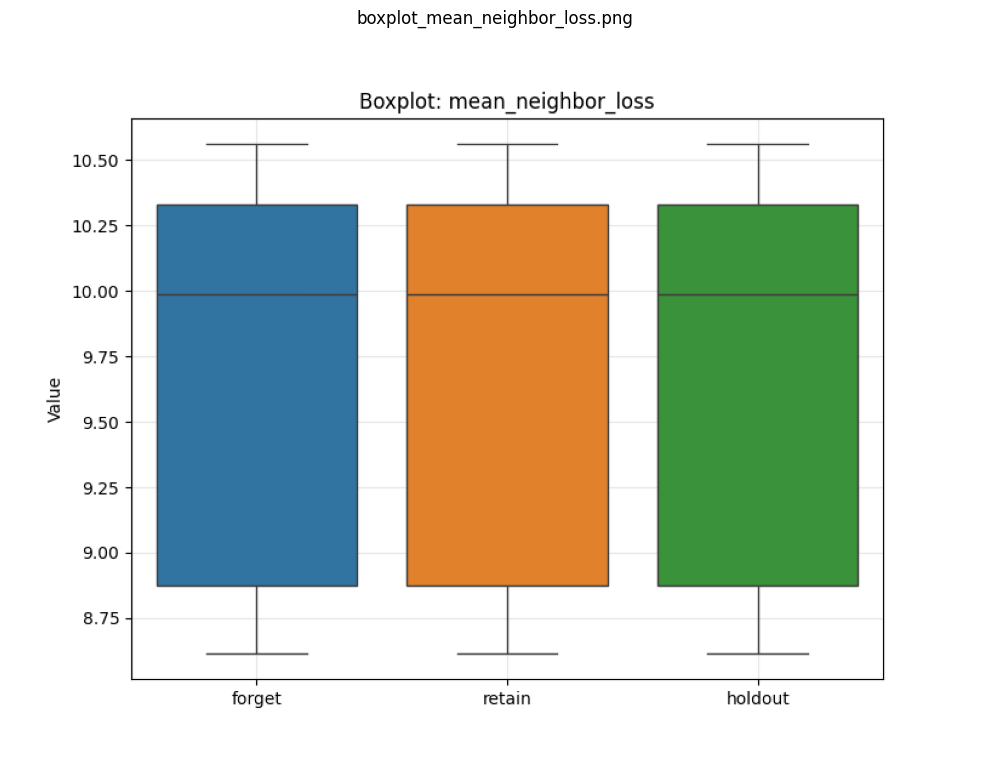

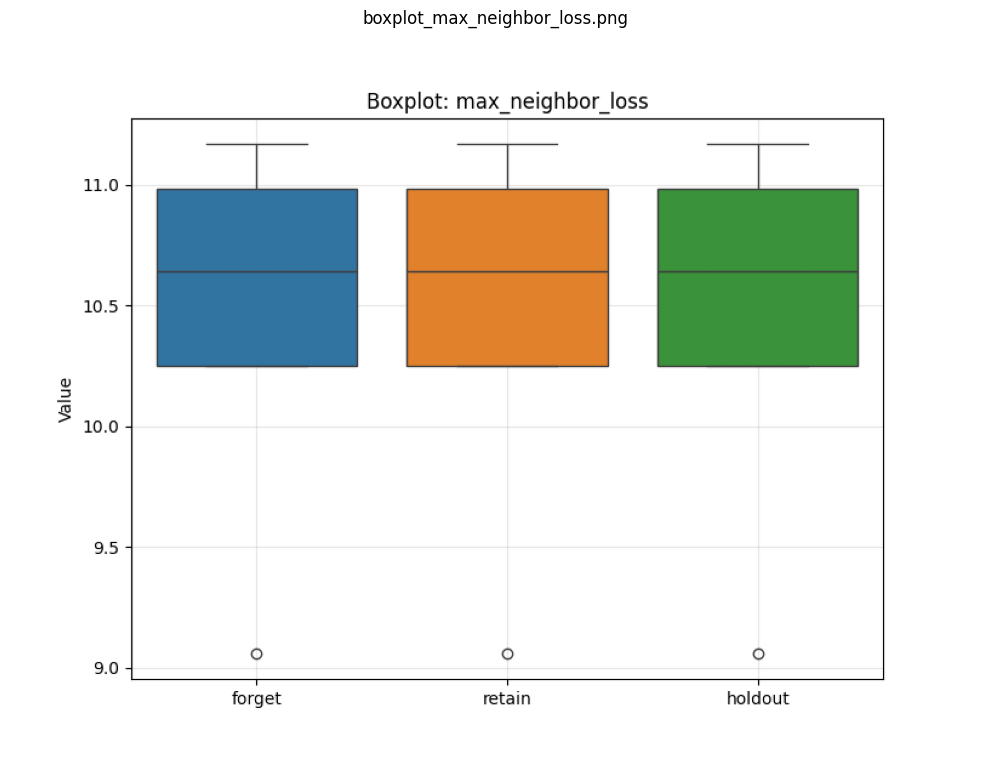

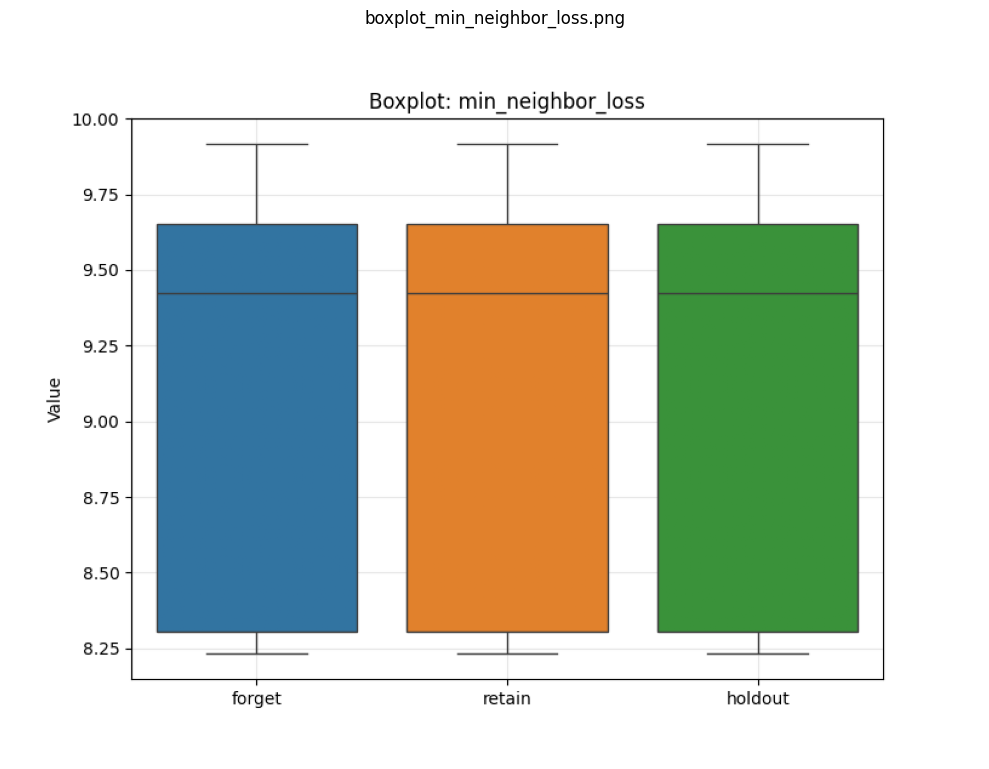

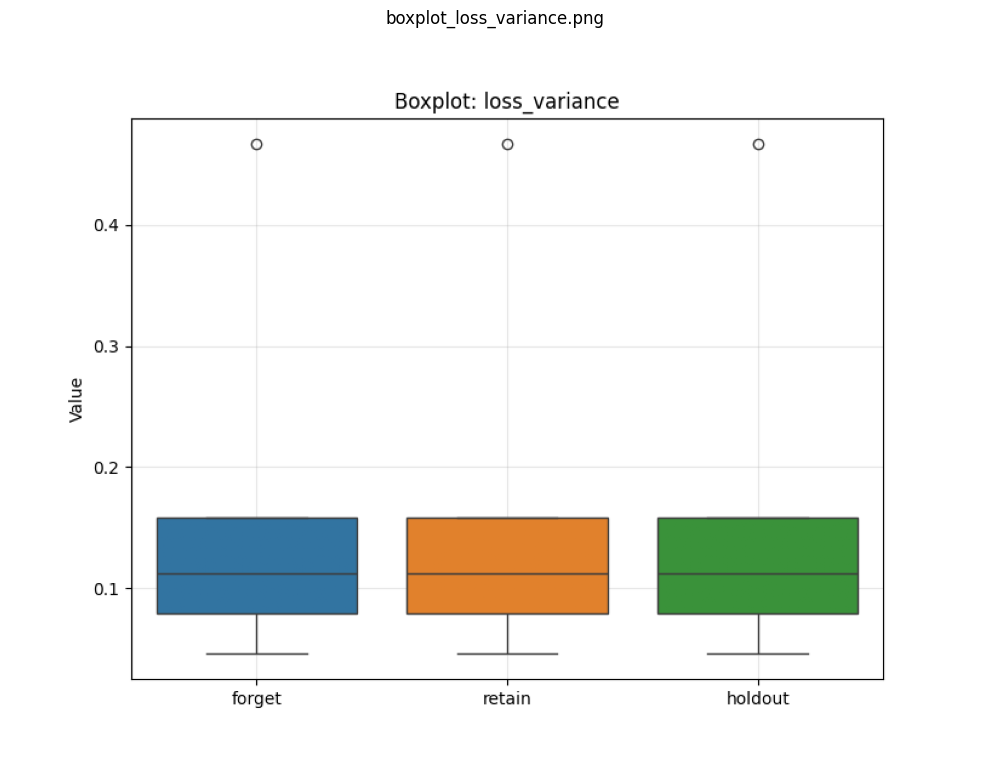

In [26]:
def show_plots(plots: dict):
    """
    Display plots from the dictionary, handling different file types appropriately.
    
    Args:
        plots: Dictionary of plot paths or nested dictionaries
    """
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    import pandas as pd
    import os
    
    if plots:
        for key, plt_obj in plots.items():
            if isinstance(plt_obj, dict):
                show_plots(plt_obj)
            elif isinstance(plt_obj, str) and os.path.isfile(plt_obj):
                # Handle different file types
                file_ext = os.path.splitext(plt_obj)[1].lower()
                
                if file_ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']:
                    # Handle image files
                    img = mpimg.imread(plt_obj)
                    plt.figure(figsize=(10, 8))
                    plt.imshow(img)
                    plt.axis('off')
                    plt.title(os.path.basename(plt_obj))
                    plt.tight_layout()
                    plt.show()
                
                elif file_ext == '.csv':
                    # Handle CSV files by displaying them as tables
                    df = pd.read_csv(plt_obj)
                    print(f"CSV file: {os.path.basename(plt_obj)}")
                    display(df.head(20))  # Show first 20 rows
                    print(f"[Showing 20/{len(df)} rows from {plt_obj}]")
                    
                else:
                    # For any other file type
                    print(f"Cannot display {plt_obj}: unsupported file type {file_ext}")
                
show_plots(loss_landscape_plots)

In [ ]:
#save dataset as json
generated_data.to_json(output_file, orient='records', indent=4)

AttributeError: 'dict' object has no attribute 'to_json'

In [21]:
import datasets
import json
output_file = '/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/distilgpt2-finetuned-wikitext2/top_k_20_n_tokens_13_k_neighbors_15/forget_data.json'
with open(output_file, 'r') as f:
    dataset = datasets.Dataset.from_list(json.load(f))
dataset

Dataset({
    features: ['text', 'valid_example', 'neighbors', 'original_output', 'mean_neighbors_loss'],
    num_rows: 30
})

In [ ]:

with open(output_file, 'r') as f:
    data = json.load(f)
dataset = datasets.Dataset.from_dict(data)
# dataset.to_json(output_file, orient="records", indent=4)
dataset

Dataset({
    features: ['text', 'valid_example', 'neighbors', 'original_output', 'mean_neighbors_loss'],
    num_rows: 15
})

In [49]:
dataset[1]

{'text': 'friend had done was the "ultimate betrayal and humiliation".\n\nShe says: "I re',
 'valid_example': True,
 'neighbors': [{'replacement': 'original',
   'text': 'friend had done was the "ultimate betrayal and humiliation".\n\nShe says: "I re'},
  {'replacement': 'She <- His, ation <- ATOR, I <- That, : <- ?:, ili <- ġ, ult <- Ext',
   'text': 'friend had done was the "Extimate betrayal and humġATOR".\n\nHis says?: "That re'},
  {'replacement': 'ult <- Ext, imate <- ĠexternalToEVA, She <- His, : <- ?:',
   'text': 'friend had done was the "ExtĠexternalToEVA betrayal and humiliation".\n\nHis says?: "I re'},
  {'replacement': 'She <- His, ult <- Ext, ray <- raise, : <- ?:, ". <- ."[',
   'text': 'friend had done was the "Extimate betraiseal and humiliation."[\n\nHis says?: "I re'},
  {'replacement': '". <- ."[, ray <- raise, She <- His, imate <- ĠexternalToEVA, ult <- Ext, ili <- ġ',
   'text': 'friend had done was the "ExtĠexternalToEVA betraiseal and humġation."[\n\nHis says: "

In [5]:
import json


privleak_forget_file = 'data/news/privleak/forget.json'
privleak_retain_file = 'data/news/privleak/retain.json'
privleak_holdout_file = 'data/news/privleak/holdout.json'

def read_json(fpath: str):
    with open(fpath, 'r') as f:
        return json.load(f)

forget_data = read_json(privleak_forget_file)
retain_data = read_json(privleak_retain_file)
holdout_data = read_json(privleak_holdout_file)

subset_len = 15
forget_data = forget_data[:subset_len]
retain_data = retain_data[:subset_len]
holdout_data = holdout_data[:subset_len]

    
len(forget_data), len(retain_data), len(holdout_data)

(15, 15, 15)

In [8]:
# show plots if available
def show_plots(plots: dict):
    if plots:
        import matplotlib.pyplot as plt
        for plot_name, plt_obj in plots.items():
            if isinstance(plt_obj, dict):
                show_plots(plt_obj)
            else:
                plt.figure()
                plt_obj.show()
                plt.close()
                
def show_plots(plots: dict):
    if plots:
        for plot_name, plt_obj in plots.items():
            if isinstance(plt_obj, dict):
                show_plots(plt_obj)
            else:
                plt_obj.show()
                
show_plots(plots)


In [ ]:
os.path.join(os.getcwd(), out_file_full)

'/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE/simnpo_news_eval.csv'